# Análisis Exploratorio de Datos (EDA) del Índice de Riesgo de la Calidad del Agua (IRCA) en Colombia

Este notebook presenta un Análisis Exploratorio de Datos (EDA) del dataset `IRCA_LIMPIO_FINAL.csv`, que contiene información histórica sobre los indicadores de riesgo de la calidad del agua a nivel departamental en Colombia, desde el año 2007 hasta 2024. El objetivo principal fue identificar y visualizar las tendencias y distribuciones de los niveles de riesgo (general, urbano y rural) en el agua.

Este análisis forma parte del proyecto **PROYECTO FINAL DE ANÁLISIS DE DATOS
NIVEL INTEGRADOR**.

**Integrantes del equipo:**
*   Erica Julieth Panqueva Méndez
*   Sandra Milena Villegas Serna
*   Carlos A. Cárdenas Hernández
*   Andrea Juliana González Cárdenas

El notebook se encuentra organizado en cuatro secciones principales:

1.  **Carga Inicial y Limpieza de Datos:** Cargamos el conjunto de datos `IRCA_LIMPIO_FINAL.csv` y realizamos pasos iniciales de limpieza de datos, incluyendo el manejo de caracteres especiales y conversiones de tipos de datos.
2.  **Análisis Exploratorio de Datos (EDA) sobre Datos IRCA:**
    *   Realizamos estadísticas descriptivas, identificamos valores nulos y generamos un informe EDA en HTML.
    *   Analizamos la evolución de los niveles de riesgo a lo largo del tiempo a nivel departamental, incluyendo gráficos de barras apiladas y gráficos de líneas.
    *   Identificamos los departamentos con los valores IRCA promedio más altos y más bajos.
    *   Realizamos un análisis comparativo entre los valores IRCA urbanos y rurales, introduciendo una métrica de 'brecha_irca_ur'.
    *   Visualizamos las tendencias del IRCA para departamentos específicos y comparamos las distribuciones de riesgo entre diferentes años.
3.  **Carga y Preprocesamiento de Datos de 'Relación de muestras':**
    *   Cargamos con éxito el conjunto de datos `Relación de muestras.xlsx`, limpiamos los nombres de las columnas, analizamos las fechas, convertimos las columnas numéricas y calculamos las coordenadas decimales a partir del formato DMS.
    *   Reordenamos las columnas para colocar las coordenadas geográficas junto a los códigos DANE.
    *   Realizamos un EDA sobre este nuevo conjunto de datos, incluyendo análisis de valores nulos, estadísticas descriptivas para parámetros clave (como pH, temperatura, turbidez), histogramas y análisis de correlación.
4.  **Modelos de Aprendizaje Automático Exploratorios:**
    *   **Modelo de Predicción de pH:** Construimos un modelo de regresión lineal para predecir 'Resultado pH' y analizamos sus coeficientes estandarizados. Notamos que este modelo tuvo un rendimiento deficiente, lo que sugiere relaciones no lineales o la falta de características clave.
    *   **Modelos de Predicción de Turbidez:** Implementamos modelos de Regresión Ridge y RandomForest Regressor para predecir 'Turbiedad'.
    *   **Modelos de Predicción del % IRCA:** Implementamos modelos de Regresión Ridge y RandomForest Regressor para predecir '% IRCA (Laboratorio).
      

# **1. Carga Inicial y Limpieza de Datos:**

In [ ]:
# Librerias de trabajo
import pandas as pd

# Cargar el archivo original
# Nota: Se usa encoding latin-1 por los caracteres especiales de departamentos y municipios
df = pd.read_csv('1_RESULTADOS_HISTORICOS_2007_2024_OLD.csv', encoding='latin-1')

df.head()

,DepartamentoCodigo,Departamento,MunicipioCodigo,Municipio,Año,IRCA,Nivel de riesgo,IRCAurbano,Nivel de riesgo urbano,IRCArural,Nivel de riesgo rural
0,91,Amazonas,#TODOS,#TODOS,"2,024",7.2,Bajo riesgo,7.6,Bajo riesgo,2.4,Sin riesgo
1,91,Amazonas,91001,Leticia,"2,024",4.9,Sin riesgo,4.9,Sin riesgo,ND,ND
2,91,Amazonas,91540,Puerto Nariño,"2,024",14.1,Riesgo medio,18.5,Riesgo medio,2.4,Sin riesgo
3,5,Antioquia,#TODOS,#TODOS,"2,024",5.2,Bajo riesgo,2.4,Sin riesgo,15.3,Riesgo medio
4,5,Antioquia,5001,MedellÃ­n,"2,024",1.3,Sin riesgo,0.7,Sin riesgo,3,Sin riesgo


In [ ]:
df.tail()

,DepartamentoCodigo,Departamento,MunicipioCodigo,Municipio,Año,IRCA,Nivel de riesgo,IRCAurbano,Nivel de riesgo urbano,IRCArural,Nivel de riesgo rural
19155,99,Vichada,99001,Puerto CarreÃ±o,"2,007",32.8,Riesgo medio,32.8,Riesgo medio,ND,ND
19156,99,Vichada,99524,La Primavera,"2,007",20.3,Riesgo medio,20.3,Riesgo medio,ND,ND
19157,99,Vichada,99624,Santa RosalÃ­a,"2,007",82.1,Inviable sanitariamente,82.1,Inviable sanitariamente,ND,ND
19158,99,Vichada,99773,Cumaribo,"2,007",26.1,Riesgo medio,26.1,Riesgo medio,ND,ND
19159,99,Vichada,#TODOS,#TODOS,"2,007",33.5,Riesgo medio,33.5,Riesgo medio,ND,ND


In [ ]:
# 1. Limpiar la columna Año (quitar comillas, puntos y comas) y convertir a entero
# Ejemplo: "2,024" -> 2024
# Mantenemos el nombre de la columna 'Año' como solicitado.
df['Año'] = df['Año'].astype(str).str.replace('"', '').str.replace(',', '').str.replace('.', '').astype(int)

# 2. Reemplazar "ND" por vacío (NULL para MySQL)
df = df.replace('ND','')

# 3. Corregir nombres de columnas para que sean compatibles con SQL
# Se mantiene 'Año' como nombre de la columna para el año.
df.columns = [
    'depto_cod', 'depto_nombre', 'muni_cod', 'muni_nombre', 'Año',
    'irca_general', 'riesgo_general', 'irca_urbano', 'riesgo_urbano',
    'irca_rural', 'riesgo_rural'
]

# 4. Limpiar caracteres especiales en nombres de municipios y departamentos (UTF-8)
# Reemplazando la función 'limpiar_texto' por reemplazos específicos para corregir mojibake
# sin afectar otras cadenas correctamente codificadas como 'Puerto Nariño'.
df['depto_nombre'] = df['depto_nombre'].str.replace('Archipielago de San Andrs, Providencia y Santa Catalina', 'Archipielago de San Andrés, Providencia y Santa Catalina')
df['depto_nombre'] = df['depto_nombre'].str.replace('Nario', 'Nariño')
df['depto_nombre'] = df['depto_nombre'].str.replace('GuainÃ­a', 'Guainí­a')
df['muni_nombre'] = df['muni_nombre'].str.replace('MedellÃ­n', 'Medellín')
df['muni_nombre'] = df['muni_nombre'].str.replace('BogotÃ¡', 'Bogotá')
df['muni_nombre'] = df['muni_nombre'].str.replace('Puerto CarreÃ±o', 'Puerto Carreño')
df['muni_nombre'] = df['muni_nombre'].str.replace('AbriaquÃ­', 'Abriaquí')
df['muni_nombre'] = df['muni_nombre'].str.replace('AlejandrÃ­a', 'Alejandría')
df['muni_nombre'] = df['muni_nombre'].str.replace('AmagÃ¡', 'Amagá')

df['muni_cod'] = df['muni_cod'].replace('#TODOS', 0)
df['muni_nombre'] = df['muni_nombre'].replace('#TODOS', 'TODOS')

# 5. Guardar el archivo corregido con todas las filas
df.to_csv('IRCA_LIMPIO_FINAL.csv', sep=',', index=False, encoding='utf-8')

print("¡Procesamiento completado! Se ha generado IRCA_LIMPIO_FINAL.csv con todos los registros.")

¡Procesamiento completado! Se ha generado IRCA_LIMPIO_FINAL.csv con todos los registros.


In [ ]:
# Cargar el archivo CSV limpio
df_limpio = pd.read_csv('IRCA_LIMPIO_FINAL.csv', encoding='utf-8')

# Mostrar las primeras 5 filas del DataFrame limpio
display(df_limpio.head())

,depto_cod,depto_nombre,muni_cod,muni_nombre,Año,irca_general,riesgo_general,irca_urbano,riesgo_urbano,irca_rural,riesgo_rural
0,91,Amazonas,0,TODOS,2024,7.2,Bajo riesgo,7.6,Bajo riesgo,2.4,Sin riesgo
1,91,Amazonas,91001,Leticia,2024,4.9,Sin riesgo,4.9,Sin riesgo,NaN,NaN
2,91,Amazonas,91540,Puerto Nariño,2024,14.1,Riesgo medio,18.5,Riesgo medio,2.4,Sin riesgo
3,5,Antioquia,0,TODOS,2024,5.2,Bajo riesgo,2.4,Sin riesgo,15.3,Riesgo medio
4,5,Antioquia,5001,Medellín,2024,1.3,Sin riesgo,0.7,Sin riesgo,3.0,Sin riesgo


In [ ]:
# Mostrar las últimas 5 filas del DataFrame limpio
display(df_limpio.tail())

,depto_cod,depto_nombre,muni_cod,muni_nombre,Año,irca_general,riesgo_general,irca_urbano,riesgo_urbano,irca_rural,riesgo_rural
19155,99,Vichada,99001,Puerto Carreño,2007,32.8,Riesgo medio,32.8,Riesgo medio,NaN,NaN
19156,99,Vichada,99524,La Primavera,2007,20.3,Riesgo medio,20.3,Riesgo medio,NaN,NaN
19157,99,Vichada,99624,Santa RosalÃ­a,2007,82.1,Inviable sanitariamente,82.1,Inviable sanitariamente,NaN,NaN
19158,99,Vichada,99773,Cumaribo,2007,26.1,Riesgo medio,26.1,Riesgo medio,NaN,NaN
19159,99,Vichada,0,TODOS,2007,33.5,Riesgo medio,33.5,Riesgo medio,NaN,NaN


In [ ]:
# Suma los valores nulos
print(df_limpio.isnull().sum())

# Da el valor de los nulos en %
df_limpio.isnull().sum() / len(df) * 100

depto_cod            0
depto_nombre         0
muni_cod             0
muni_nombre          0
Año                  0
irca_general         0
riesgo_general       0
irca_urbano       1268
riesgo_urbano     1268
irca_rural        9615
riesgo_rural      9615
dtype: int64


,0
depto_cod,0.000000
depto_nombre,0.000000
muni_cod,0.000000
muni_nombre,0.000000
Año,0.000000
irca_general,0.000000
riesgo_general,0.000000
irca_urbano,6.617954
riesgo_urbano,6.617954
irca_rural,50.182672


# **2. Análisis Exploratorio de Datos (EDA) sobre Datos IRCA:**

## Descripción del Dataset `IRCA_LIMPIO_FINAL.csv`

Este dataset contiene información histórica sobre el Índice de Riesgo de la Calidad del Agua (IRCA) a nivel municipal y departamental en Colombia, desde el año 2007 hasta 2024. Los datos incluyen indicadores de riesgo general, urbano y rural.

El **IRCA** (Índice de Riesgo de la Calidad del Agua) en Colombia mide el grado de riesgo sanitario asociado al consumo de agua según sus características físicas, químicas y microbiológicas. Se expresa en porcentaje (0-100%) y clasifica el agua en niveles de riesgo que van desde “sin riesgo” hasta “inviable sanitariamente”.

📊 **Cómo se mide el IRCA**
Base legal: Decreto 1575 de 2007 y Resolución 2115 de 2007.

**Parámetros evaluados:**

*   **Físicos:** turbidez, color, olor, sabor.
*   **Químicos:** pH, cloro residual, metales pesados, nitratos, entre otros.
*   **Microbiológicos:** coliformes totales, coliformes fecales, E. coli.

**Metodología:**
Se toman muestras de agua en diferentes puntos del sistema de abastecimiento.

Se comparan los resultados con los valores máximos permitidos por la normatividad.
Se calcula un porcentaje de incumplimiento que determina el nivel de riesgo.

**Interpretación:** El IRCA refleja la probabilidad de que el agua cause enfermedades de origen hídrico si no cumple con los estándares de calidad.


## Descripción de Variables (Columnas)

A continuación, se detalla cada columna del dataset:

| Nombre de la Variable | Tipo de Dato | Descripción                                                                |
| :-------------------- | :----------- | :------------------------------------------------------------------------- |
| `depto_cod`           | `int64`      | Código numérico del departamento.                                          |
| `depto_nombre`        | `object`     | Nombre del departamento.                                                   |
| `muni_cod`            | `int64`      | Código numérico del municipio. `0` indica un registro a nivel departamental. |
| `muni_nombre`         | `object`     | Nombre del municipio. `TODOS` se usa para registros a nivel departamental. |
| `anio`                | `int64`      | Año del registro.                                                          |
| `irca_general`        | `float64`    | Índice de Riesgo de la Calidad del Agua (IRCA) general.                    |
| `riesgo_general`      | `object`     | Categoría de riesgo general, basada en el `irca_general`.                |
| `irca_urbano`         | `float64`    | IRCA para la zona urbana. **(6.62% de valores nulos)**                     |
| `riesgo_urbano`       | `object`     | Categoría de riesgo para la zona urbana. **(6.62% de valores nulos)**    |
| `irca_rural`          | `float64`    | IRCA para la zona rural. **(50.18% de valores nulos)**                     |
| `riesgo_rural`        | `object`     | Categoría de riesgo para la zona rural. **(50.18% de valores nulos)**    |

### 🚦 Niveles de riesgo del IRCA
| Rango (%) | Nivel de riesgo         | Interpretación                                                      |
| :-------- | :---------------------- | :----------------------------------------------------------------- |
| 0 – 5     | Sin riesgo              | Agua apta para consumo humano.                                     |
| >5 – 14   | Riesgo bajo             | Agua generalmente apta, pero con pequeñas deficiencias.           |
| >14 – 35  | Riesgo medio            | Agua con deficiencias que pueden afectar la salud; requiere intervención. |
| >35 – 80  | Riesgo alto             | Agua no apta para consumo humano; riesgo significativo de enfermedades. |
| >80 – 100 | Inviable sanitariamente | Agua totalmente inadecuada para consumo; representa grave peligro para la salud. |


### Observaciones sobre valores nulos (NaN)
Como se observa en el análisis de nulos, las columnas relacionadas con la zona rural (`irca_rural`, `riesgo_rural`) tienen una gran cantidad de valores `NaN`, lo que indica que para aproximadamente la mitad de los registros no hay datos específicos de IRCA rural. Las columnas de la zona urbana (`irca_urbano`, `riesgo_urbano`) también presentan algunos nulos, aunque en menor proporción.

In [ ]:
print('Información general del DataFrame:')
df_limpio.info()

Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19160 entries, 0 to 19159
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   depto_cod       19160 non-null  int64  
 1   depto_nombre    19160 non-null  object 
 2   muni_cod        19160 non-null  int64  
 3   muni_nombre     19160 non-null  object 
 4   Año             19160 non-null  int64  
 5   irca_general    19160 non-null  float64
 6   riesgo_general  19160 non-null  object 
 7   irca_urbano     17892 non-null  float64
 8   riesgo_urbano   17892 non-null  object 
 9   irca_rural      9545 non-null   float64
 10  riesgo_rural    9545 non-null   object 
dtypes: float64(3), int64(3), object(5)
memory usage: 1.6+ MB


### Análisis Estadístico de Niveles de Riesgo a Nivel Nacional

Vamos a analizar cómo han evolucionado los diferentes niveles de riesgo de la calidad del agua (`riesgo_general`) a nivel departamental (considerado aquí como representación nacional al sumar los departamentos) a lo largo de los años. Esto nos permitirá identificar tendencias y cambios en la calidad del agua en Colombia.

In [ ]:
# Librerias de trabajo
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')

# Filtrar Datos a Nivel Departamental
df_dept = df_limpio[(df_limpio['muni_cod'] == 0) & (df_limpio['muni_nombre'] == 'TODOS')].copy()

# Definir el orden de las categorías de riesgo para una visualización consistente
risk_order = [
    'Sin riesgo',
    'Riesgo bajo',
    'Riesgo medio',
    'Riesgo alto',
    'Inviable sanitariamente'
]

# Contar la ocurrencia de cada nivel de riesgo por año en el dataframe departamental
risk_counts = df_dept.groupby(['Año', 'riesgo_general']).size().unstack(fill_value=0)

# Reordenar las columnas según el orden de riesgo definido
risk_counts = risk_counts[risk_order]

display(risk_counts.head())

riesgo_general,Sin riesgo,Riesgo bajo,Riesgo medio,Riesgo alto,Inviable sanitariamente
Año,,,,,
2007,0,6,16,7,2
2008,2,4,17,7,1
2009,2,5,17,6,0
2010,4,3,16,8,0
2011,5,1,19,4,1


### Visualización de la Evolución de Niveles de Riesgo por Año

Para una mejor comprensión de las tendencias, graficaremos estos conteos. Un gráfico de barras apiladas o un gráfico de líneas para cada categoría de riesgo nos permitirá observar cómo ha cambiado la proporción de departamentos en cada nivel de riesgo a lo largo de los años.

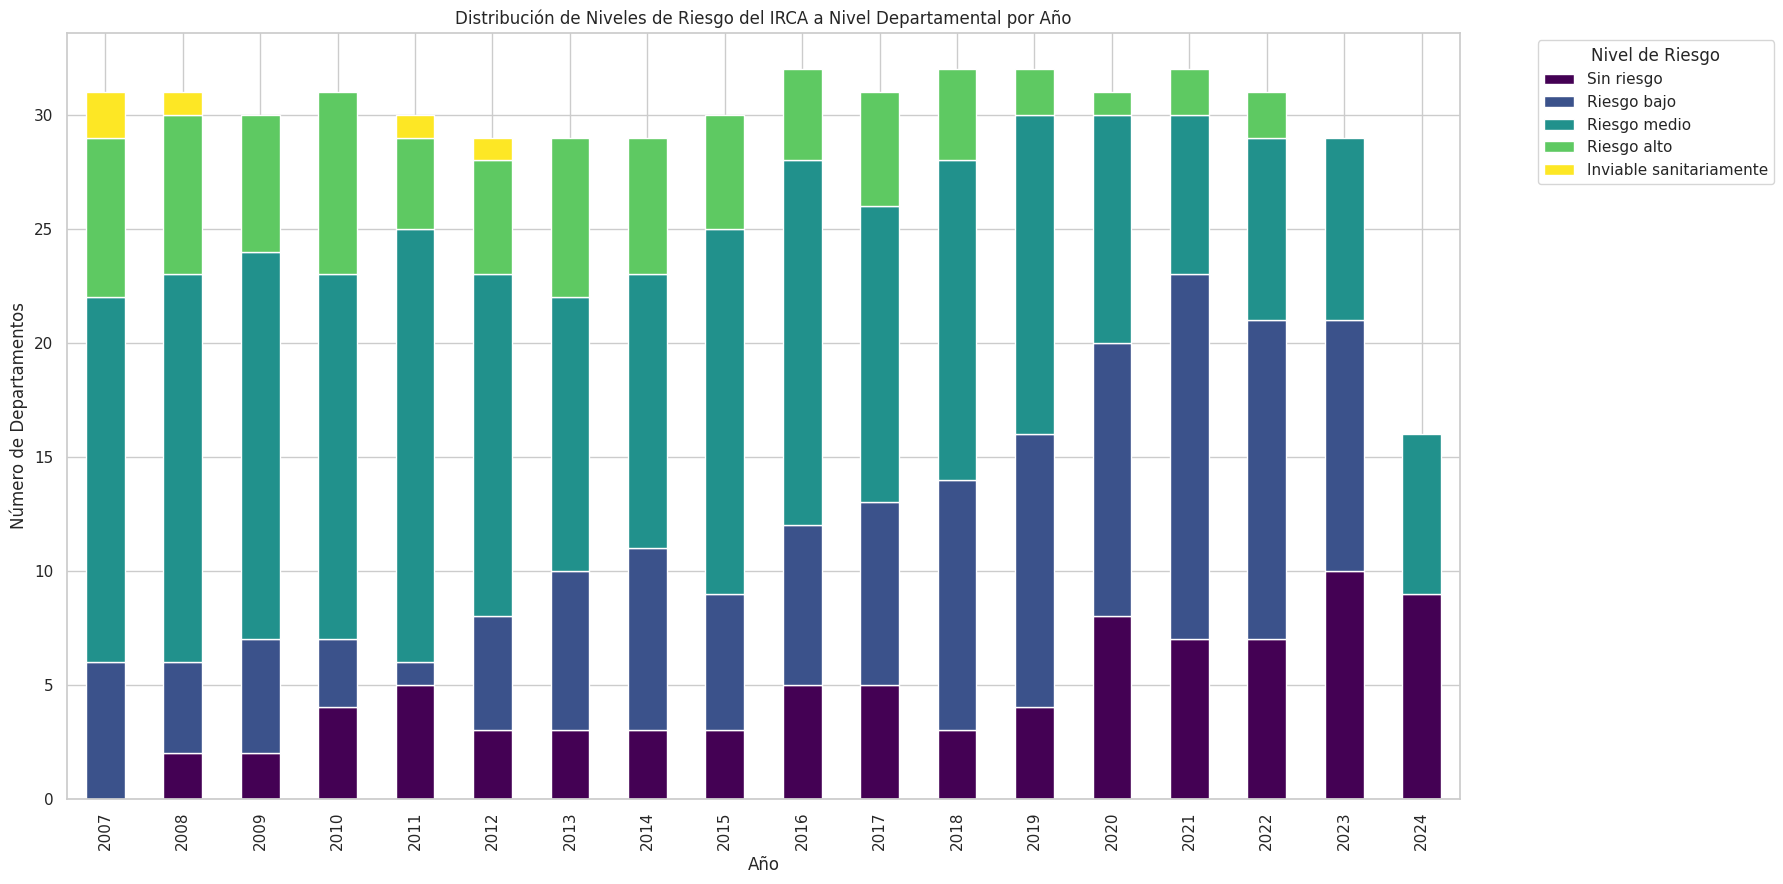

In [ ]:
# Gráfico de barras apiladas de los niveles de riesgo a lo largo de los años
risk_counts.plot(kind='bar', stacked=True, figsize=(18, 9), cmap='viridis')
plt.title('Distribución de Niveles de Riesgo del IRCA a Nivel Departamental por Año')
plt.xlabel('Año')
plt.ylabel('Número de Departamentos')
plt.legend(title='Nivel de Riesgo', bbox_to_anchor=(1.05, 1), loc='upper left') # Mover la leyenda fuera del gráfico
plt.tight_layout()
plt.show()


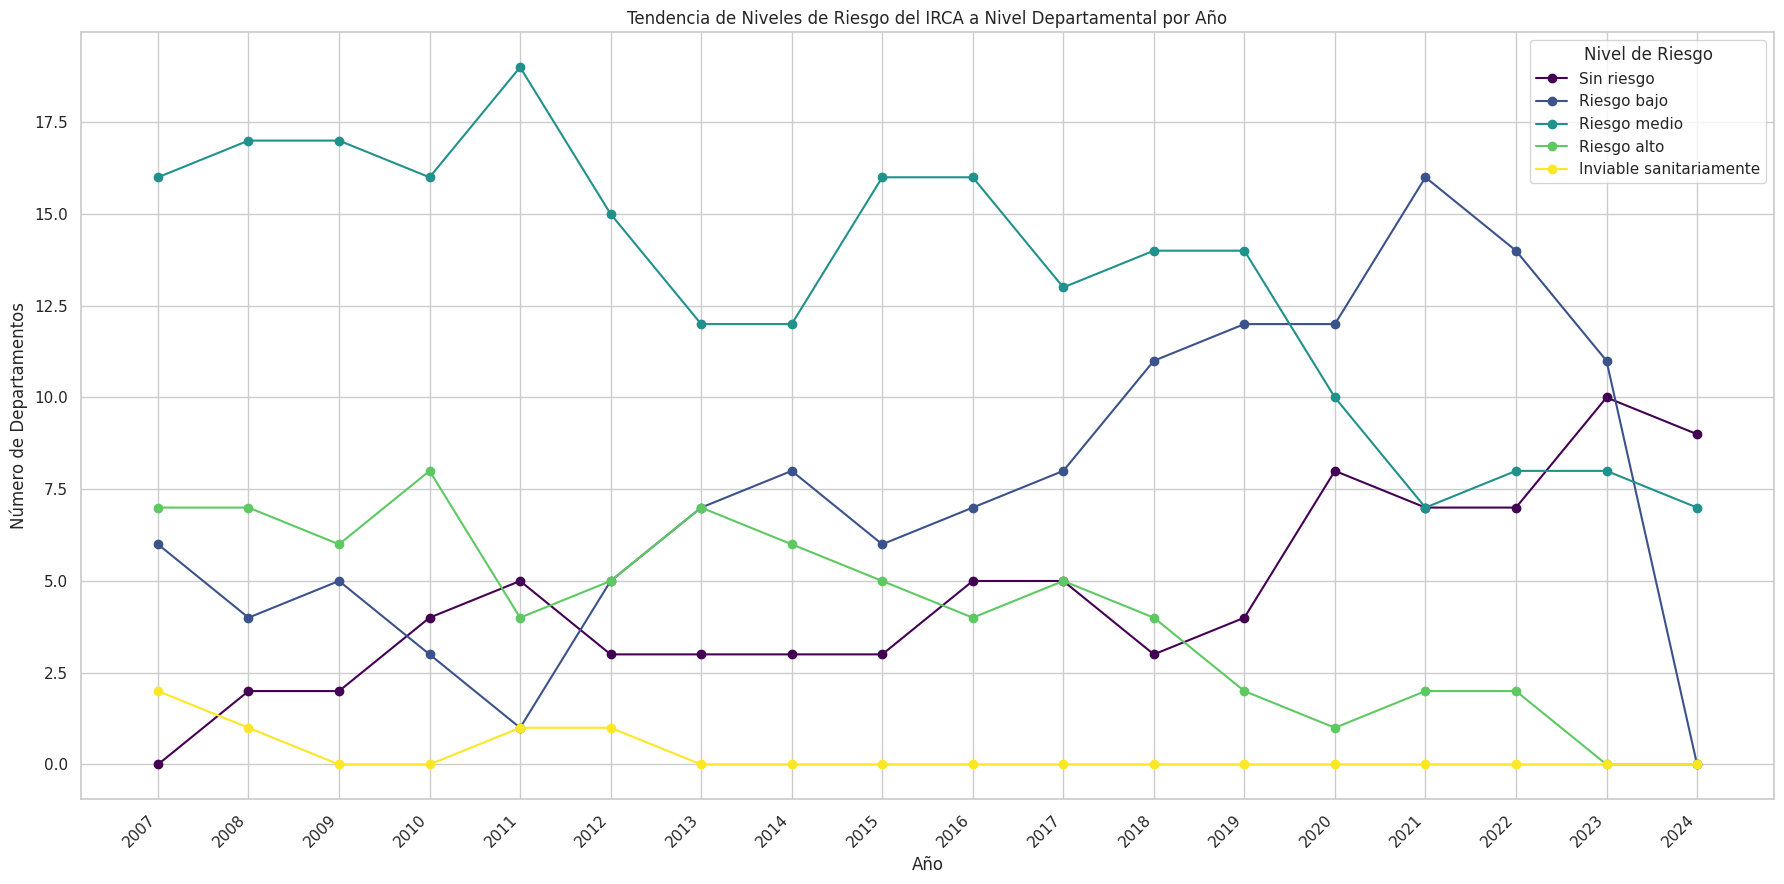

In [ ]:
# Gráfico de líneas para mostrar tendencias individuales de cada nivel de riesgo
risk_counts.plot(kind='line', figsize=(18, 9), marker='o', cmap='viridis')
plt.title('Tendencia de Niveles de Riesgo del IRCA a Nivel Departamental por Año')
plt.xlabel('Año')
plt.ylabel('Número de Departamentos')
plt.xticks(risk_counts.index, rotation=45, ha='right') # Mostrar todos los años
plt.legend(title='Nivel de Riesgo')
plt.grid(True)
plt.tight_layout()
plt.show()

### Filtrar Datos a Nivel Departamental

Primero, vamos a crear un nuevo DataFrame que contenga únicamente los registros a nivel departamental. Según la descripción de las variables, estos son aquellos donde `muni_cod` es `0` y `muni_nombre` es `'TODOS'`.

In [ ]:
df_dept = df_limpio[(df_limpio['muni_cod'] == 0) & (df_limpio['muni_nombre'] == 'TODOS')].copy()
display(df_dept.head())

,depto_cod,depto_nombre,muni_cod,muni_nombre,Año,irca_general,riesgo_general,irca_urbano,riesgo_urbano,irca_rural,riesgo_rural
0,91,Amazonas,0,TODOS,2024,7.2,Bajo riesgo,7.6,Bajo riesgo,2.4,Sin riesgo
3,5,Antioquia,0,TODOS,2024,5.2,Bajo riesgo,2.4,Sin riesgo,15.3,Riesgo medio
127,81,Arauca,0,TODOS,2024,5.7,Bajo riesgo,0.8,Sin riesgo,34.2,Riesgo medio
135,88,"Archipielago de San Andrés, Providencia y Sant...",0,TODOS,2024,3.6,Sin riesgo,0.5,Sin riesgo,8.5,Bajo riesgo
137,8,Atlántico,0,TODOS,2024,1.1,Sin riesgo,0.3,Sin riesgo,7.5,Bajo riesgo


### Análisis Descriptivo Detallado

In [135]:
print('Estadísticas básicas para columnas numéricas a nivel departamental:')
display(df_dept[['irca_general', 'irca_urbano', 'irca_rural']].describe())


Estadísticas básicas para columnas numéricas a nivel departamental:


,irca_general,irca_urbano,irca_rural
count,551.000000,547.000000,474.000000
mean,19.839927,15.900731,32.299789
std,15.904983,15.882598,23.592752
min,0.000000,0.000000,0.000000
25%,7.750000,4.200000,10.775000
50%,16.300000,11.300000,28.300000
75%,27.150000,22.700000,50.750000
max,100.000000,100.000000,100.000000


### Identificación de Departamentos Destacados (Top/Bottom)

In [ ]:
# IRCA general promedio por departamento a lo largo de todos los años
avg_irca_dept = df_dept.groupby('depto_nombre')['irca_general'].mean().sort_values(ascending=False)

print('Top 5 Departamentos con el IRCA General promedio más alto (2007-2024):')
display(avg_irca_dept.head())

print('\nTop 5 Departamentos con el IRCA General promedio más bajo (2007-2024):')
display(avg_irca_dept.tail())

Top 5 Departamentos con el IRCA General promedio más alto (2007-2024):


,irca_general
depto_nombre,
Vaupés,50.538462
Caldas,40.127778
Putumayo,38.127778
Nariño,37.944444
Guainí­a,34.786667



Top 5 Departamentos con el IRCA General promedio más bajo (2007-2024):


,irca_general
depto_nombre,
Atlántico,7.672222
Antioquia,7.305556
Cundinamarca,6.916667
Arauca,4.205556
Quindío,2.911111


In [ ]:
# Departamentos con mayor/menor tiempo en 'Inviable sanitariamente' (ejemplo)
# Contar cuántas veces un departamento estuvo en cada categoría de riesgo
risk_time_counts = df_dept.groupby('depto_nombre')['riesgo_general'].value_counts().unstack(fill_value=0)

if 'Inviable sanitariamente' in risk_time_counts.columns:
    # Filtrar solo los departamentos que tienen un conteo > 0 para 'Inviable sanitariamente'
    inviable_sanitariamente_counts = risk_time_counts['Inviable sanitariamente']
    filtered_inviable_sanitariamente = inviable_sanitariamente_counts[inviable_sanitariamente_counts > 0]

    if not filtered_inviable_sanitariamente.empty:
        print('\nDepartamentos con mayor número de años en Inviable sanitariamente:')
        display(filtered_inviable_sanitariamente.sort_values(ascending=False).head())
    else:
        print('\nNo hay registros de departamentos que hayan estado en la categoría "Inviable sanitariamente" (con conteo > 0).')
else:
    print('\nNo hay registros de "Inviable sanitariamente" para analizar el tiempo.')


Departamentos con mayor número de años en Inviable sanitariamente:


,Inviable sanitariamente
depto_nombre,
Vaupés,4
Guaviare,1


### Comparación Urbano vs. Rural

En este análisis'brecha' se refiere a la diferencia en el Índice de Riesgo de la Calidad del Agua (IRCA) entre la zona urbana y la zona rural de un departamento. Se calcula como:

brecha_irca_ur = irca_urbano - irca_rural

El IRCA es un índice que mide el riesgo: un valor más bajo indica menor riesgo (mejor calidad del agua) y un valor más alto indica mayor riesgo (peor calidad del agua).

*   Si brecha_irca_ur es **POSITIVA**: Significa que irca_urbano es mayor que irca_rural. Esto implica que la calidad del agua urbana tiene un MAYOR riesgo (es PEOR) que la calidad del agua rural.

*   Si brecha_irca_ur es **NEGATIVA**: Significa que irca_urbano es menor que irca_rural. Esto implica que la calidad del agua urbana tiene un MENOR riesgo (es MEJOR) que la calidad del agua rural.

Por lo tanto, los valores negativos en 'brecha_irca_ur' indican que, en esos casos, la calidad del agua en las zonas urbanas es, en promedio, mejor (con menor riesgo) que en las zonas rurales del mismo departamento.

Departamentos con mayor brecha (IRCA Urbano - IRCA Rural):


,brecha_irca_ur
depto_nombre,
Amazonas,7.875000
Caquetá,-3.375000
Cundinamarca,-4.005556
"Archipielago de San Andrés, Providencia y Santa Catalina",-4.677778
Córdoba,-4.712500



Departamentos con menor brecha (IRCA Urbano - IRCA Rural) o donde el rural es mejor:


,brecha_irca_ur
depto_nombre,
Caldas,-56.827778
Huila,-46.477778
Boyacá,-31.038889
Risaralda,-30.500000
Valle del Cauca,-28.011111


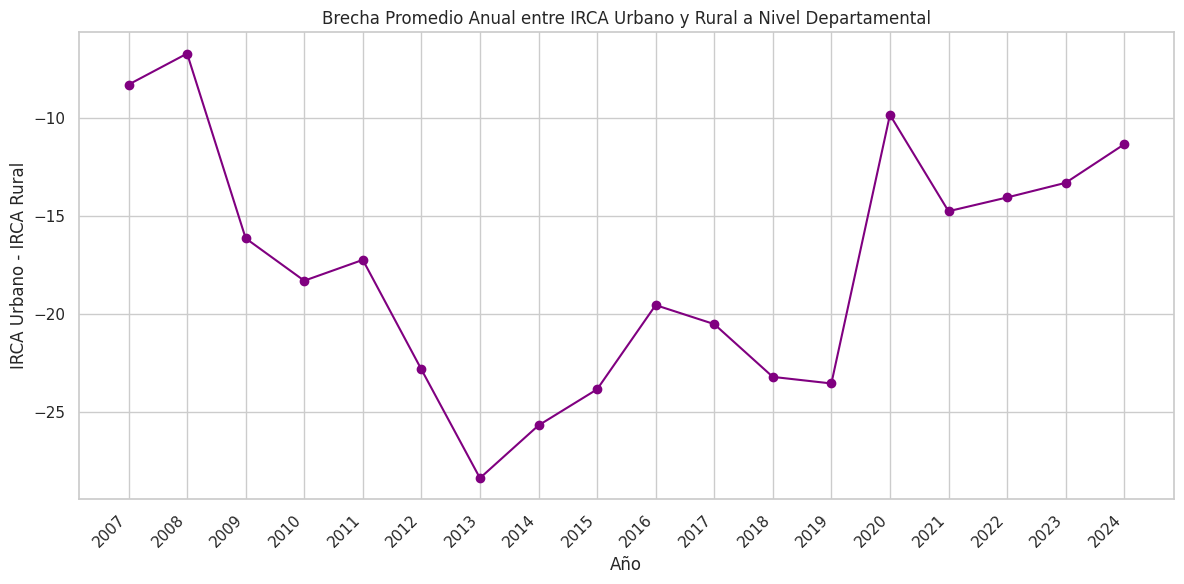

In [ ]:
# Calcular la brecha entre IRCA urbano y rural
df_dept['brecha_irca_ur'] = df_dept['irca_urbano'] - df_dept['irca_rural']

print('Departamentos con mayor brecha (IRCA Urbano - IRCA Rural):')
display(df_dept.groupby('depto_nombre')['brecha_irca_ur'].mean().sort_values(ascending=False).head())

print('\nDepartamentos con menor brecha (IRCA Urbano - IRCA Rural) o donde el rural es mejor:')
display(df_dept.groupby('depto_nombre')['brecha_irca_ur'].mean().sort_values(ascending=True).head())

# Visualización de la brecha promedio anual
brecha_anual = df_dept.groupby('Año')['brecha_irca_ur'].mean()
plt.figure(figsize=(12, 6))
brecha_anual.plot(kind='line', marker='o', color='purple')
plt.title('Brecha Promedio Anual entre IRCA Urbano y Rural a Nivel Departamental')
plt.xlabel('Año')
plt.ylabel('IRCA Urbano - IRCA Rural')
plt.xticks(brecha_anual.index, rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Análisis de Tendencias Específicas para Departamentos Específicos

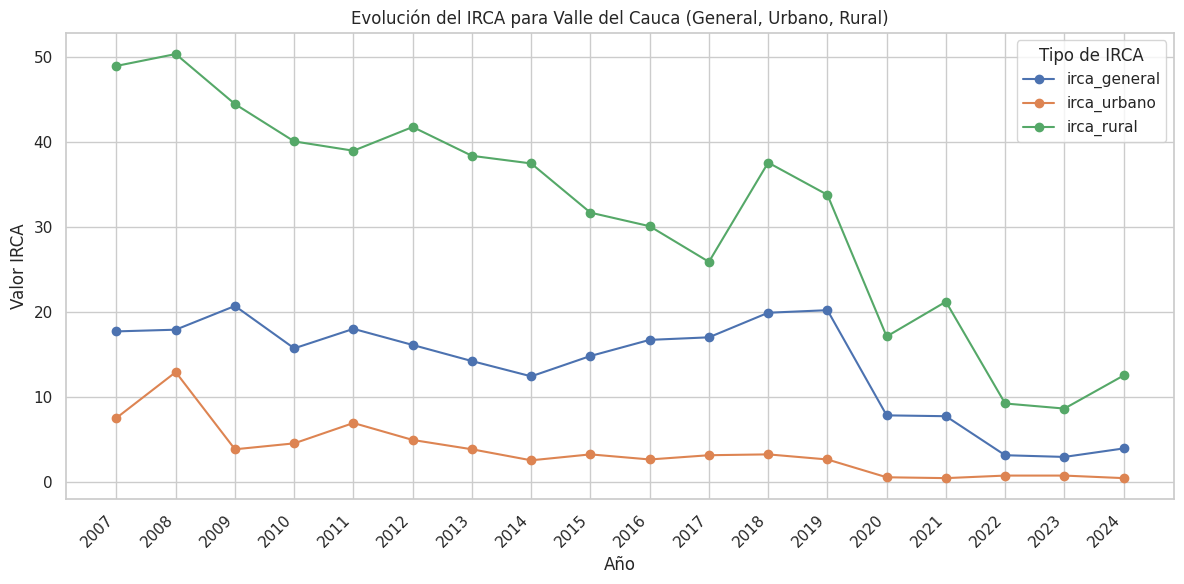

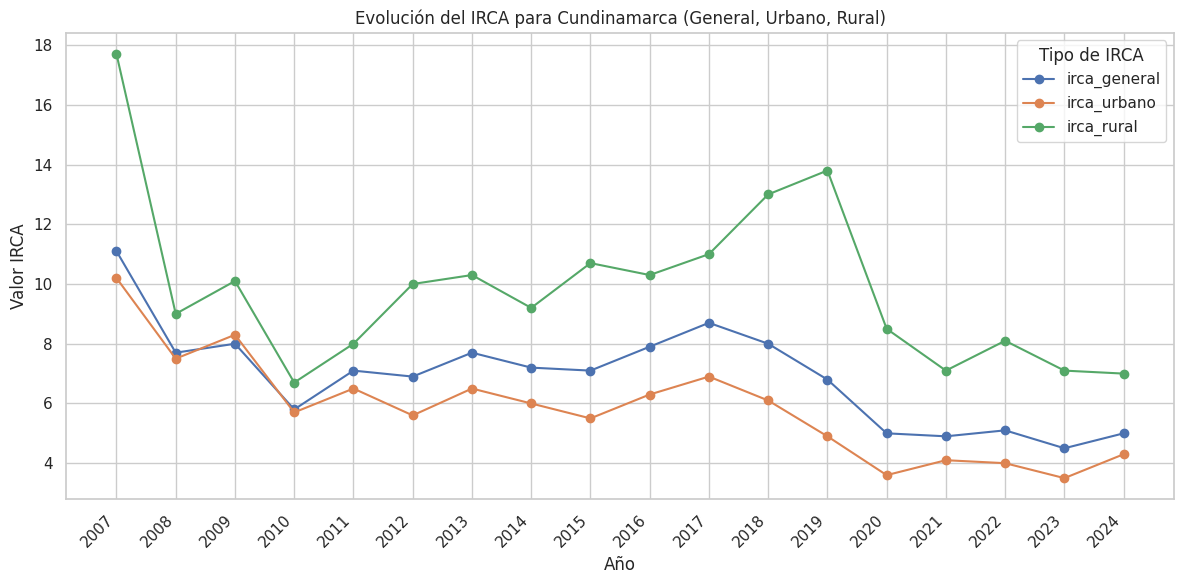

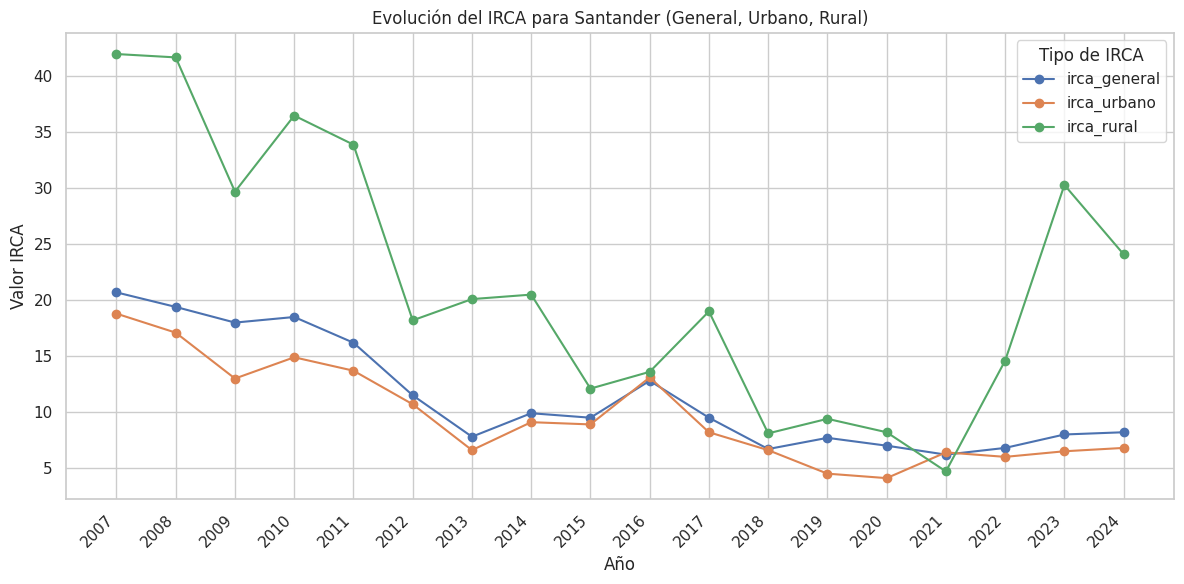

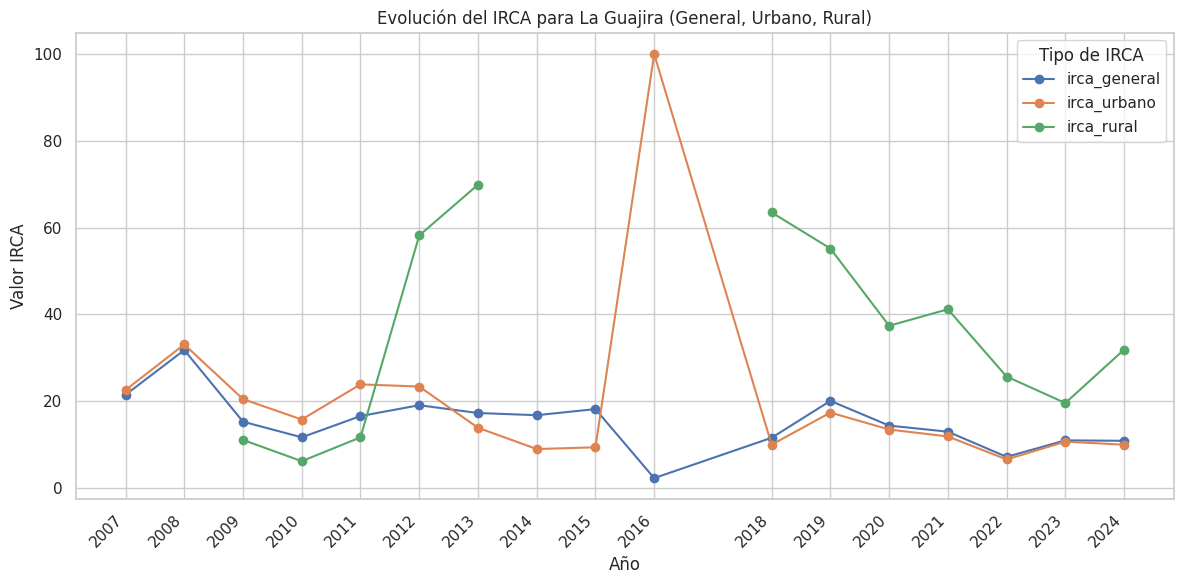

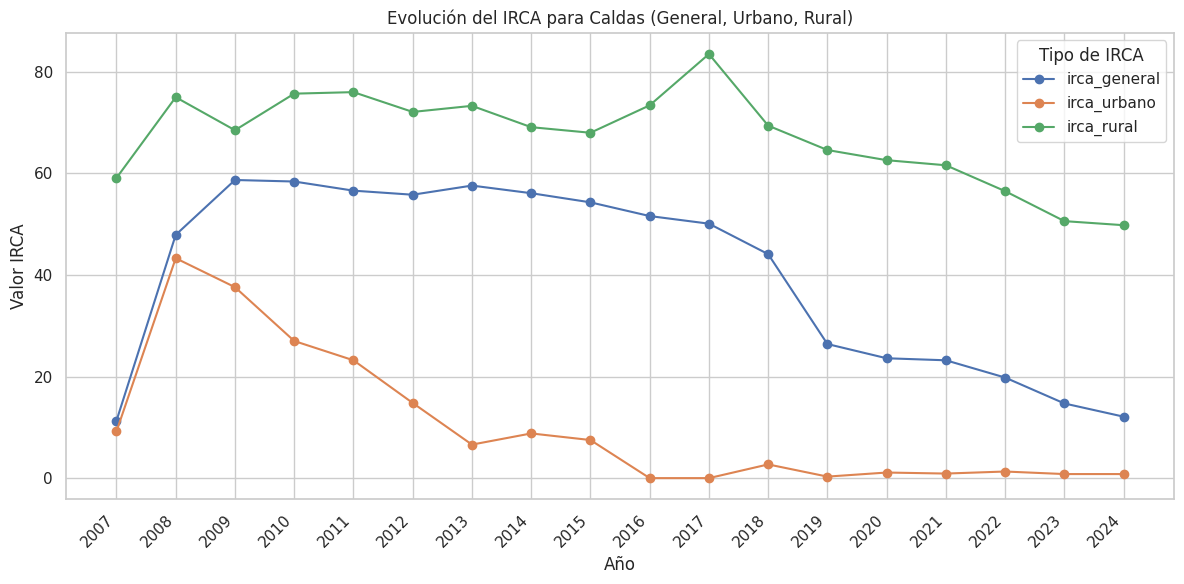

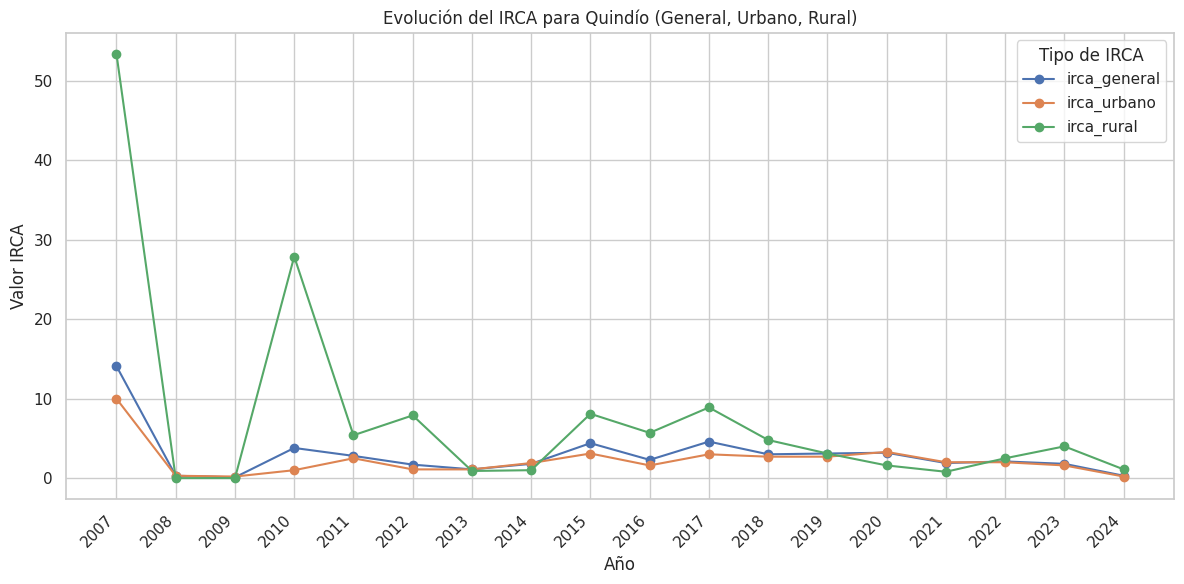

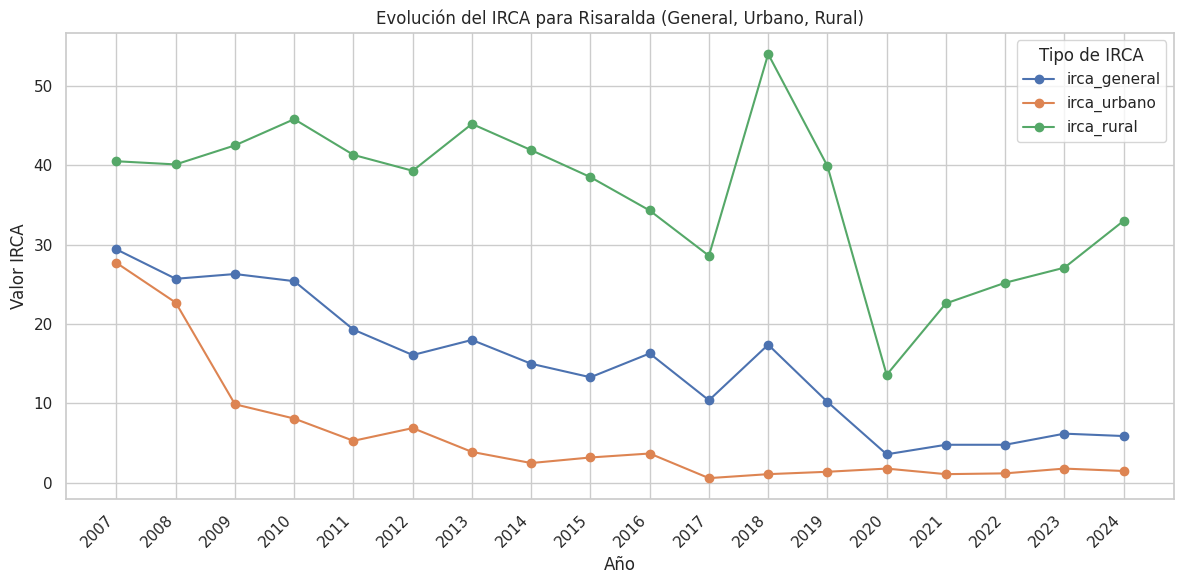

In [89]:
# Ejemplo: Evolución del IRCA para un departamento específico
import matplotlib.pyplot as plt

departamentos_interes = [
    'Antioquia','Valle del Cauca', 'Cundinamarca', 'Santander', 'La Guajira', 'Caldas', 'Quindío', 'Risaralda'
]

for depto in departamentos_interes:
    # Asegurarse de que el nombre del departamento existe en el DataFrame
    if depto not in df_dept['depto_nombre'].unique():
        print(f"Advertencia: El departamento '{depto}' no se encontró en el DataFrame. Se omitirá.")
        continue

    tendencia_depto = df_dept[df_dept['depto_nombre'] == depto].set_index('Año')

    plt.figure(figsize=(12, 6))
    tendencia_depto[['irca_general', 'irca_urbano', 'irca_rural']].plot(kind='line', marker='o', ax=plt.gca())
    plt.title(f'Evolución del IRCA para {depto} (General, Urbano, Rural)')
    plt.xlabel('Año')
    plt.ylabel('Valor IRCA')
    plt.xticks(tendencia_depto.index, rotation=45, ha='right')
    plt.grid(True)
    plt.legend(title='Tipo de IRCA')
    plt.tight_layout()
    plt.show()

### Distribución de Categorías de Riesgo para Años Específicos

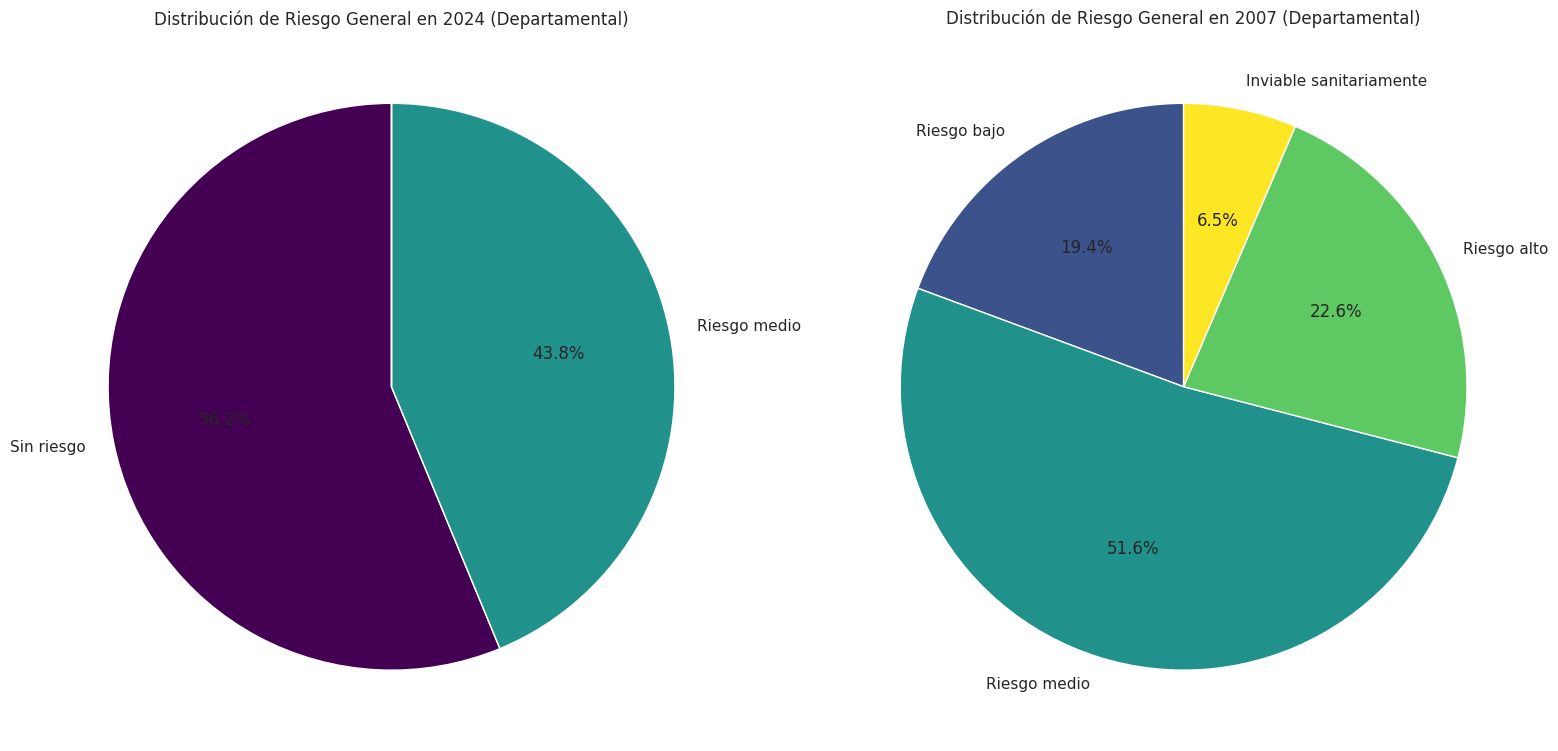

In [ ]:
# Distribución de riesgo general para el último año (2024) y un año específico (2007) en diagramas circulares lado a lado
latest_year = df_dept['Año'].max()
year_2007 = 2007

risk_distribution_latest = df_dept[df_dept['Año'] == latest_year]['riesgo_general'].value_counts(normalize=True).reindex(risk_order, fill_value=0)
risk_distribution_2007 = df_dept[df_dept['Año'] == year_2007]['riesgo_general'].value_counts(normalize=True).reindex(risk_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Función para formatear el autopct y no mostrar 0.0%
def autopct_format(pct):
    return ('%1.1f%%' % pct) if pct > 0 else ''

# Gráfico para el último año
risk_distribution_latest.plot(kind='pie', autopct=autopct_format, startangle=90, cmap='viridis', ax=axes[0])
axes[0].set_title(f'Distribución de Riesgo General en {latest_year} (Departamental)')
axes[0].set_ylabel('') # Eliminar etiqueta 'riesgo_general' del eje y

# Gráfico para el año 2007
risk_distribution_2007.plot(kind='pie', autopct=autopct_format, startangle=90, cmap='viridis', ax=axes[1])
axes[1].set_title(f'Distribución de Riesgo General en {year_2007} (Departamental)')
axes[1].set_ylabel('') # Eliminar etiqueta 'riesgo_general' del eje y

plt.tight_layout()
plt.show()

# **3. Carga y Preprocesamiento de Datos de 'Relación de muestras':**

Este notebook carga el Excel `Relación de muestras.csv`, hace una limpieza básica, crea coordenadas decimales y corre una EDA rápida (estadísticos, histogramas, correlaciones) y un modelo lineal exploratorio para `Resultado pH`.


In [ ]:
# Cargar datos (hoja principal)
import pandas as pd
excel_path = 'Relación de muestras.xlsx'
sheet_name = 'Resultados consolidados'

df_raw = pd.read_excel(excel_path, sheet_name=sheet_name)
print(df_raw.shape)
df_raw.head()

(151, 281)


,ID del prestador,Nombre del prestador,Departamento (punto de muestra),Municipio (punto de muestra),Código DANE (municipio de toma de muestra),Tipo de muestra,Producto de priorización,Criterio de priorización,Fecha de toma de la muestra\n(dd-mm-aaaa),¿El agua en el punto de muestreo es tratada?,...,Incertidumbre Abamectina,Cumplimiento Abamectina,Resultado Etion,Incertidumbre Etion,Cumplimiento Etion,Resultado Fenitrotión,Incertidumbre Fenitrotión,Cumplimiento Fenitrotión,% IRCA (Laboratorio),Nivel de riesgo (Calculado)
0,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,2,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-02,Sí,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5,Riesgo Bajo
1,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,2,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-02,Sí,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5,Sin Riesgo
2,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-03,Sí,...,0.00001,Cumple,<0.0001,0.00001,Cumple,<0.0001,0.00001,Cumple,0.0,Sin Riesgo
3,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-03,Sí,...,0.00001,Cumple,<0.0001,0.00001,Cumple,<0.0001,0.00001,Cumple,16.5,Riesgo Medio
4,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-07,Sí,...,0.00001,Cumple,<0.0001,0.00001,Cumple,<0.0001,0.00001,Cumple,0.0,Sin Riesgo


In [ ]:
# Limpieza básica: normalizar nombres de columnas
import re

def clean_col_name(col):
    col2 = str(col)
    col2 = col2.replace('\n', ' ')
    col2 = re.sub(r'\s+', ' ', col2).strip()
    return col2

df_etl = df_raw.copy()
df_etl.columns = [clean_col_name(c) for c in df_etl.columns]

# Fecha (dd-mm-aaaa)
date_col = 'Fecha de toma de la muestra (dd-mm-aaaa)'
if date_col in df_etl.columns:
    df_etl[date_col] = pd.to_datetime(df_etl[date_col], errors='coerce', dayfirst=True)

print(df_etl.shape)
df_etl.head()

(151, 281)


,ID del prestador,Nombre del prestador,Departamento (punto de muestra),Municipio (punto de muestra),Código DANE (municipio de toma de muestra),Tipo de muestra,Producto de priorización,Criterio de priorización,Fecha de toma de la muestra (dd-mm-aaaa),¿El agua en el punto de muestreo es tratada?,...,Incertidumbre Abamectina,Cumplimiento Abamectina,Resultado Etion,Incertidumbre Etion,Cumplimiento Etion,Resultado Fenitrotión,Incertidumbre Fenitrotión,Cumplimiento Fenitrotión,% IRCA (Laboratorio),Nivel de riesgo (Calculado)
0,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,2,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-02,Sí,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5,Riesgo Bajo
1,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,2,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-02,Sí,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5,Sin Riesgo
2,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-03,Sí,...,0.00001,Cumple,<0.0001,0.00001,Cumple,<0.0001,0.00001,Cumple,0.0,Sin Riesgo
3,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-03,Sí,...,0.00001,Cumple,<0.0001,0.00001,Cumple,<0.0001,0.00001,Cumple,16.5,Riesgo Medio
4,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,2024-05-07,Sí,...,0.00001,Cumple,<0.0001,0.00001,Cumple,<0.0001,0.00001,Cumple,0.0,Sin Riesgo


In [ ]:
# Convertir columnas numéricas de Resultados/Incertidumbres
num_like_cols = [c for c in df_etl.columns if c.startswith('Resultado ') or c.startswith('Incertidumbre ')]

for c in num_like_cols:
    df_etl[c] = pd.to_numeric(df_etl[c], errors='coerce')

# También intenta convertir algunas columnas que suelen ser numéricas
for c in ['% IRCA (Laboratorio)']:
    if c in df_etl.columns:
        df_etl[c] = pd.to_numeric(df_etl[c], errors='coerce')

print(len(num_like_cols))

185


**Reporte EDA**

In [ ]:
!pip install ydata-profiling -q

In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df_etl, title="Reporte de EDA")
profile.to_file("IRCA.html")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 283/283 [00:18<00:00, 15.56it/s]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Buffered data was truncated after reaching the output size limit.

In [ ]:
# Coordenadas decimales (si están las columnas de grados/min/seg)
lat_deg = 'Latitud - N - º (grados)'
lat_min = "Latitud - N - ' (minutos)"
lat_sec = "Latitud - N - '' (segundos)"

lon_deg = 'Longitud - W - º (grados)'
lon_min = "Longitud - W - ' (minutos)"
lon_sec = "Longitud - W - '' (segundos)"

def dms_to_decimal(deg, minute, sec, west_or_south=False):
    dec = deg + (minute / 60.0) + (sec / 3600.0)
    if west_or_south:
        dec = -1.0 * dec
    return dec

if all([c in df_etl.columns for c in [lat_deg, lat_min, lat_sec, lon_deg, lon_min, lon_sec]]):
    df_etl['lat_decimal'] = dms_to_decimal(df_etl[lat_deg], df_etl[lat_min], df_etl[lat_sec], west_or_south=False)
    df_etl['lon_decimal'] = dms_to_decimal(df_etl[lon_deg], df_etl[lon_min], df_etl[lon_sec], west_or_south=True)

# Vista rápida
coord_cols = [c for c in ['lat_decimal', 'lon_decimal'] if c in df_etl.columns]
if len(coord_cols) > 0:
    df_etl[coord_cols].describe().T

/tmp/ipykernel_20494/4087584108.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_etl['lat_decimal'] = dms_to_decimal(df_etl[lat_deg], df_etl[lat_min], df_etl[lat_sec], west_or_south=False)
/tmp/ipykernel_20494/4087584108.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_etl['lon_decimal'] = dms_to_decimal(df_etl[lon_deg], df_etl[lon_min], df_etl[lon_sec], west_or_south=True)


In [ ]:
#  Mostrar coordenadas decimales
current_cols = df_etl.columns.tolist()

# Identificar la columna 'Código DANE (municipio de toma de muestra)'
dane_col_index = current_cols.index('Código DANE (municipio de toma de muestra)')

new_cols = current_cols[:dane_col_index + 1] # Columns up to and including 'Código DANE'

# Solo agregue columnas de coordenadas si existen en df_etl.
if 'lat_decimal' in df_etl.columns and 'lon_decimal' in df_etl.columns:
    new_cols.append('lat_decimal')
    new_cols.append('lon_decimal')

# Agregue el resto de las columnas después de las coordenadas insertadas, asegurándose de que no haya duplicados.
for col in current_cols[dane_col_index + 1:]:
    if col not in ['lat_decimal', 'lon_decimal']:
        new_cols.append(col)

# Reindexa el DataFrame con el nuevo orden de columnas.
df_etl = df_etl[new_cols]

display(df_etl.head())

,ID del prestador,Nombre del prestador,Departamento (punto de muestra),Municipio (punto de muestra),Código DANE (municipio de toma de muestra),lat_decimal,lon_decimal,Tipo de muestra,Producto de priorización,Criterio de priorización,...,Incertidumbre Abamectina,Cumplimiento Abamectina,Resultado Etion,Incertidumbre Etion,Cumplimiento Etion,Resultado Fenitrotión,Incertidumbre Fenitrotión,Cumplimiento Fenitrotión,% IRCA (Laboratorio),Nivel de riesgo (Calculado)
0,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,4.632250,-74.111250,2,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5,Riesgo Bajo
1,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,4.754861,-74.047500,2,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.5,Sin Riesgo
2,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,4.688972,-74.025667,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,...,0.00001,Cumple,NaN,0.00001,Cumple,NaN,0.00001,Cumple,0.0,Sin Riesgo
3,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,4.973472,-73.975528,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,...,0.00001,Cumple,NaN,0.00001,Cumple,NaN,0.00001,Cumple,16.5,Riesgo Medio
4,70,Empresa de Acueducto y Alcantarillado de Bogot...,Bogotá,"Bogotá, D.C.",11001,4.575500,-74.074139,1,Proyecto de inversión (2024 - 2027) - Producto 1,Sin información SIVICAP,...,0.00001,Cumple,NaN,0.00001,Cumple,NaN,0.00001,Cumple,0.0,Sin Riesgo


In [116]:
null_rate = df_etl.isna().mean().sort_values(ascending=False)
null_df = null_rate.reset_index()
null_df.columns = ['columna', 'porcentaje_nulos']

null_df['columna'] = null_df['columna'].str.replace('Resultado ', '')
null_df.head(20)

,columna,porcentaje_nulos
0,Fenitrotión,1.0
1,Etion,1.0
2,Terbufos,1.0
3,Metolacloro,1.0
4,Alaclor,1.0
5,Metil-Paratión,1.0
6,Linuron,1.0
7,Terbutilazina,1.0
8,Ametrina,1.0
9,Diclorvos,1.0


In [ ]:
# EDA: estadísticos + histogramas de variables comunes
candidate_targets = [
    'Resultado pH',
    'Resultado Temperatura',
    'Resultado Cloro Libre',
    'Resultado Conductividad',
    'Resultado Color Aparente',
    'Resultado Turbiedad',
    'Resultado Coliformes Totales',
    'Resultado Escherichia Coli'
]

available_targets = [c for c in candidate_targets if c in df_etl.columns]

desc_df = df_etl[available_targets].describe().T

# Eliminar la palabra Resultado de la columna
desc_df.index = desc_df.index.str.replace('Resultado ', '')
display(desc_df)

,count,mean,std,min,25%,50%,75%,max
pH,150.0,7.178133,0.652103,5.87,6.6925,7.035,7.6850,8.88
Temperatura,150.0,25.263467,5.004125,11.90,21.2250,26.700,29.4000,35.10
Cloro Libre,104.0,1.414038,0.657170,0.28,1.0275,1.350,1.6625,4.30
Conductividad,141.0,260.888652,328.335102,25.70,67.2000,127.200,315.0000,1672.00
Color Aparente,46.0,26.678913,15.130193,10.00,13.8250,20.650,40.8500,59.19
Turbiedad,132.0,8.164545,23.029460,0.50,0.9500,1.800,4.3750,160.00
Coliformes Totales,47.0,140.529787,410.180958,1.00,8.0000,14.000,43.5000,1732.90
Escherichia Coli,40.0,23.890000,59.193229,1.00,2.0000,6.000,20.0000,344.00


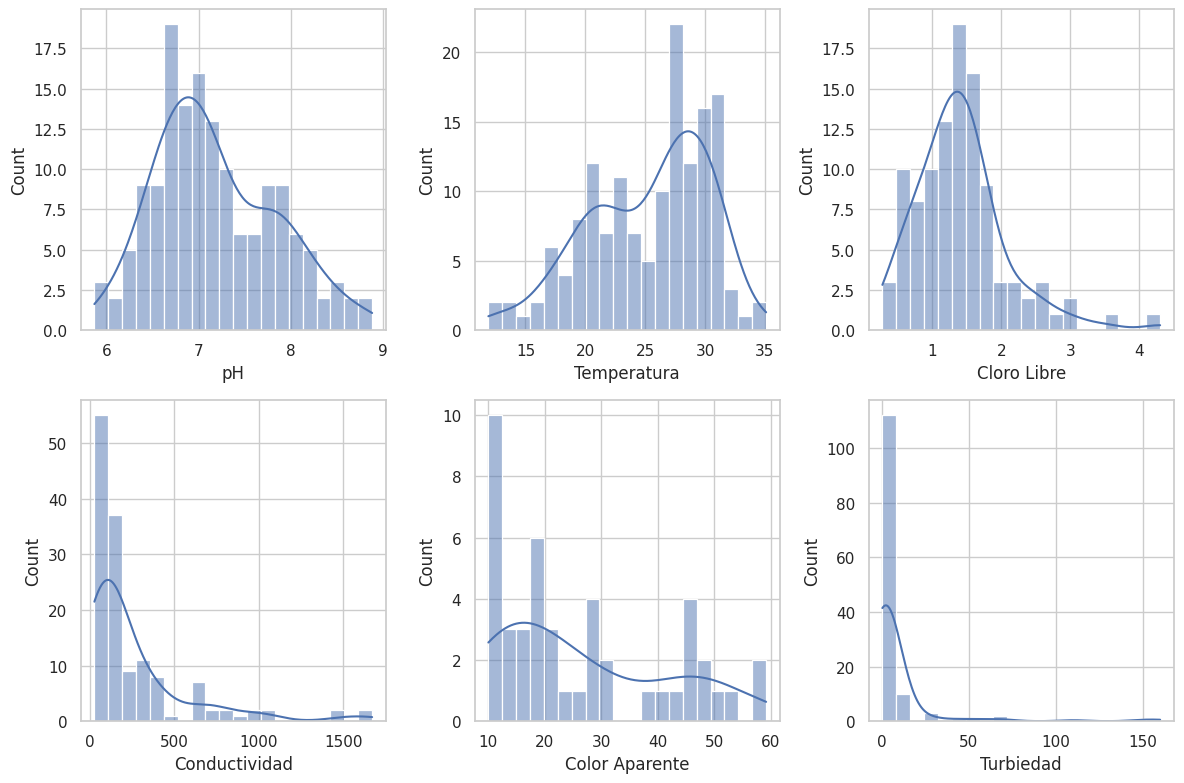

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogramas
plot_cols = available_targets[:6]
fig = plt.figure(figsize=(12, 8))
for idx, col in enumerate(plot_cols, start=1):
    plt.subplot(2, 3, idx)
    sns.histplot(df_etl[col].dropna(), kde=True, bins=20)
    plt.xlabel(col.replace('Resultado ', '')) # Eliminar 'Resultado ' de la etiqueta del eje X
plt.tight_layout()
plt.show()

,variable,correlacion_con_pH
0,Resultado Alcalinidad Total,0.382140
1,% IRCA (Laboratorio),0.237087
2,Resultado Conductividad,0.210643
3,Resultado Cloro Libre,0.150530
4,Resultado Nitratos,0.145281
5,Resultado Turbiedad,0.140708
6,Resultado real Cloro Libre,-0.092205
7,Resultado Sulfatos,0.080857
8,Resultado Magnesio,-0.074806
9,Resultado Calcio,-0.051651


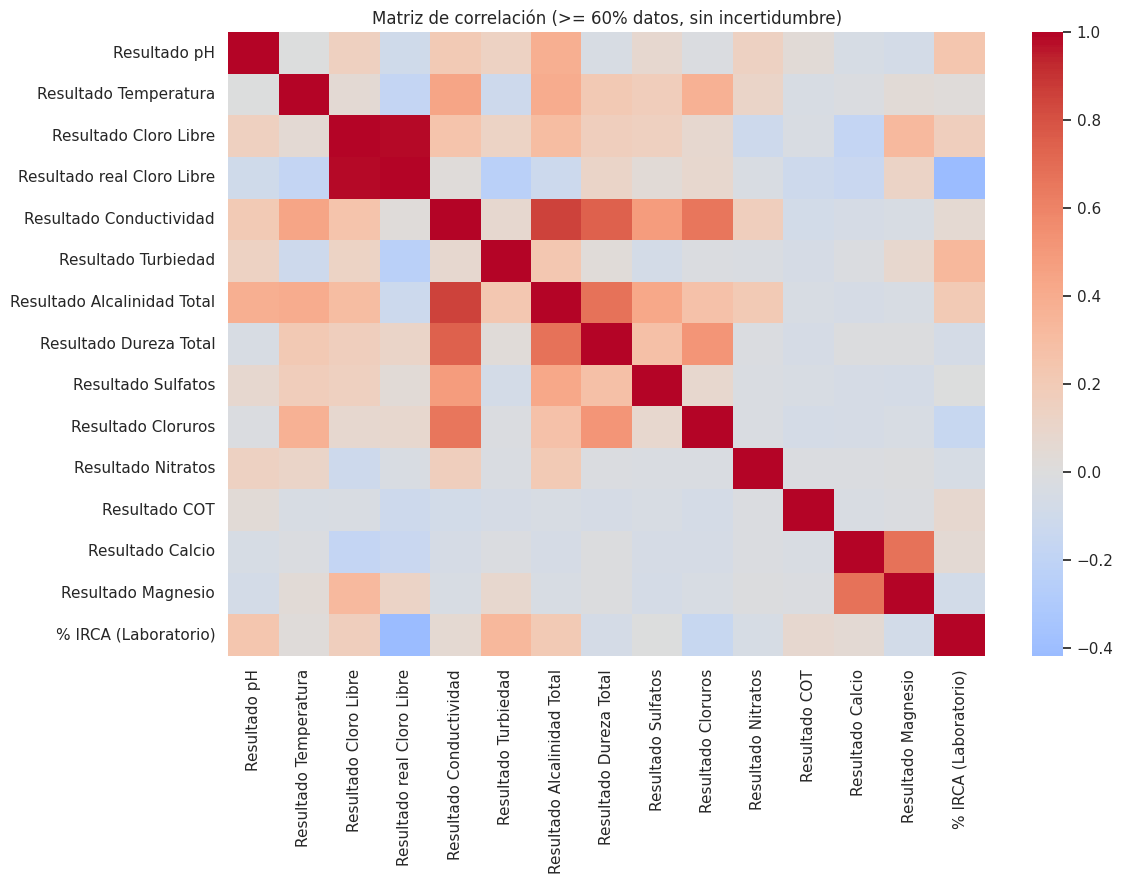

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Correlaciones (variables numéricas con suficiente cobertura)
num_df = df_etl.select_dtypes(include=[np.number]).copy()

# Excluir varibales explícitamente
exclude_cols_corr = [
    'ID del prestador',
    'Código DANE (municipio de toma de muestra)',
    'lat_decimal',
    'lon_decimal',
    'Tipo de muestra',
    'Latitud - N - º (grados)',
    "Latitud - N - ' (minutos)",
    "Latitud - N - '' (segundos)",
    'Longitud - W - º (grados)',
    "Longitud - W - ' (minutos)",
    "Longitud - W - '' (segundos)"
]
num_df = num_df.drop(columns=[col for col in exclude_cols_corr if col in num_df.columns])

non_null_rate_num = 1 - num_df.isna().mean()
keep_cols = non_null_rate_num[non_null_rate_num >= 0.6].index.tolist()

# Excluir explícitamente las columnas de 'Incertidumbre' del análisis de correlación
keep_cols = [col for col in keep_cols if 'Incertidumbre' not in col]

num_keep = num_df[keep_cols]
corr_mat = num_keep.corr(numeric_only=True)

# Top correlaciones con pH (si existe)
if 'Resultado pH' in corr_mat.columns:
    pH_corr = corr_mat['Resultado pH'].drop('Resultado pH').dropna().sort_values(key=lambda s: s.abs(), ascending=False)
    top_pH_corr = pH_corr.head(15).reset_index()
    top_pH_corr.columns = ['variable', 'correlacion_con_pH']
    display(top_pH_corr)

plt.figure(figsize=(12, 9))
sns.heatmap(corr_mat, cmap='coolwarm', center=0, square=False)
plt.title('Matriz de correlación (>= 60% datos, sin incertidumbre)')
plt.tight_layout()
plt.show()

#**4. Modelos de Aprendizaje Automático Exploratorios:**

### Modelo lineal exploratorio para pH (solo como diagnóstico)

El **coeficiente estandarizado** Indica la magnitud y dirección de la relación entre cada variable predictora y la variable objetivo (en este caso, 'Resultado pH'), después de que todas las variables han sido estandarizadas (escaladas para tener una media de cero y una desviación estándar de uno).

*   **Comparabilidad:** Al estandarizar los coeficientes, puedes comparar directamente la importancia relativa de cada predictor en el modelo, incluso si las variables originales tienen unidades de medida muy diferentes. Un coeficiente estandarizado más grande (en valor absoluto) indica que esa variable tiene un mayor impacto en el `Resultado pH`, en comparación con otras variables en el modelo.

*   **Dirección:**
    *   Un **valor positivo** (`coef_estandarizado > 0`) significa que a medida que la variable predictora aumenta, el `Resultado pH` tiende a aumentar también, manteniendo las demás variables constantes.
    *   Un **valor negativo** (`coef_estandarizado < 0`) significa que a medida que la variable predictora aumenta, el `Resultado pH` tiende a disminuir, manteniendo las demás variables constantes.

*   **Magnitud:** El número en sí representa el cambio en el `Resultado pH` (en desviaciones estándar) por cada desviación estándar de cambio en la variable predictora, asumiendo que las demás variables se mantienen constantes.



In [98]:
# Modelo lineal exploratorio para pH (solo como diagnóstico)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

target_col = 'Resultado pH'

if target_col in df_etl.columns:
    # Re-aplicar la misma lógica de filtrado de columnas que en el análisis de correlación
    num_df_filtered = df_etl.select_dtypes(include=[np.number]).copy()

    # Excluir las mismas columnas que se excluyeron en el cálculo de correlación
    exclude_cols_corr = [
        'ID del prestador', 'Código DANE (municipio de toma de muestra)', 'lat_decimal', 'lon_decimal',
        'Tipo de muestra', 'Latitud - N - º (grados)', "Latitud - N - ' (minutos)", "Latitud - N - '' (segundos)",
        'Longitud - W - º (grados)', "Longitud - W - ' (minutos)", "Longitud - W - '' (segundos)"
    ]
    num_df_filtered = num_df_filtered.drop(columns=[col for col in exclude_cols_corr if col in num_df_filtered.columns])

    non_null_rate_num = 1 - num_df_filtered.isna().mean()
    # Filtrar columnas con cobertura >= 60% y que no sean 'Incertidumbre' ni la columna objetivo
    predictor_cols = [
        c for c in non_null_rate_num[non_null_rate_num >= 0.6].index.tolist()
        if 'Incertidumbre' not in c and c != target_col
    ]

    model_df = df_etl[[target_col] + predictor_cols].copy()
    model_df = model_df.dropna(subset=[target_col])

    X = model_df[predictor_cols]
    y = model_df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

    pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"R2: {r2}")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")

    coef_vals = pipe.named_steps['lr'].coef_
    coef_df = pd.DataFrame({'variable': predictor_cols, 'coef_estandarizado': coef_vals})
    coef_df['abs_coef'] = coef_df['coef_estandarizado'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False).drop(columns=['abs_coef'])
    # Eliminar la palabra "Resultado " de la columna 'variable'
    coef_df['variable'] = coef_df['variable'].str.replace('Resultado ', '')
    display(coef_df.head(20))

R2: -1790.2967754169774
MAE: 6.020775596650681
RMSE: 26.246167080851816


,variable,coef_estandarizado
5,Alcalinidad Total,0.501190
6,Dureza Total,-0.332421
2,real Cloro Libre,0.135583
13,% IRCA (Laboratorio),0.118202
8,Cloruros,0.109103
4,Turbiedad,0.108743
0,Temperatura,-0.107833
1,Cloro Libre,-0.060640
12,Magnesio,-0.054393
3,Conductividad,-0.046999


Estos coeficientes muestran que Resultado Alcalinidad Total y Resultado Dureza Total tienen la mayor influencia, aunque, el bajo R2 del modelo nos dice que esta relación lineal es una representación muy pobre de la realidad. Esto sugiere que las relaciones entre estas variables y el pH no son lineales o que faltan características clave que capturen la variabilidad del pH.

# Modelos para predecir la turbidez utilizando variables químicas

### Explicación del Análisis de Predicción de Turbidez

Este análisis se centró en predecir el **Resultado de Turbidez** utilizando diversas variables químicas del conjunto de datos. Para ello, se emplearon dos modelos de aprendizaje automático:

1.  **Regresión Ridge:** Es un tipo de regresión lineal que incorpora regularización para evitar el sobreajuste. Aunque útil en muchos escenarios, en este caso particular, su rendimiento fue muy bajo.
2.  **RandomForest Regressor:** Este es un método de aprendizaje de conjunto que construye múltiples árboles de decisión durante el entrenamiento y promedia sus predicciones. Generalmente, es un modelo robusto y eficaz en diversos tipos de datos. En nuestro análisis, el modelo Random Forest demostró una capacidad predictiva excelente.


In [117]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

target_col2 = 'Resultado Turbiedad'

# Obtener todas las columnas numéricas de df_etl
num_df_all = df_etl.select_dtypes(include=[np.number]).copy()

# Excluir las columnas de identificadores que no son características predictivas.
exclude_id_cols = ['ID del prestador', 'Código DANE (municipio de toma de muestra)', 'lat_decimal',
    'lon_decimal', 'Latitud - N - º (grados)', "Latitud - N - ' (minutos)", "Latitud - N - '' (segundos)",
    'Longitud - W - º (grados)', "Longitud - W - ' (minutos)", "Longitud - W - '' (segundos)",
    'Tipo de muestra']
num_df_all = num_df_all.drop(columns=[col for col in exclude_id_cols if col in num_df_all.columns])

# Calcular la tasa de valores no nulos para estas columnas numéricas.
non_null_rate_all_num = 1 - num_df_all.isna().mean()

# Filtra las columnas con al menos un 60 % de valores no nulos y excluye la columna objetivo.
# Excluye todas las columnas 'Incertidumbre'
feature_cols2 = [
    c for c in non_null_rate_all_num[non_null_rate_all_num >= 0.6].index.tolist()
    if c != target_col2 and 'Incertidumbre' not in c
]

# Crea un modelo_df específicamente para la predicción de turbidez, eliminando las filas donde el objetivo sea NaN.
model_df_turbidity = df_etl[[target_col2] + feature_cols2].copy()
model_df_turbidity = model_df_turbidity.dropna(subset=[target_col2])

X = model_df_turbidity[feature_cols2]
y = model_df_turbidity[target_col2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))
])

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=3,
        n_jobs=-1
    ))
])

ridge_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

pred_ridge = ridge_pipe.predict(X_test)
pred_rf = rf_pipe.predict(X_test)

rmse_ridge = float(np.sqrt(mean_squared_error(y_test, pred_ridge)))
rmse_rf = float(np.sqrt(mean_squared_error(y_test, pred_rf)))

metrics_df = pd.DataFrame({
    'modelo': ['Ridge', 'RandomForest'],
    'R2': [r2_score(y_test, pred_ridge), r2_score(y_test, pred_rf)],
    'MAE': [mean_absolute_error(y_test, pred_ridge), mean_absolute_error(y_test, pred_rf)],
    'RMSE': [rmse_ridge, rmse_rf]
}).sort_values('R2', ascending=False)

print(metrics_df)

# Coeficientes
# Se usa feature_cols2 para ridge_coefs ya que representa las columnas usadas en el entrenamiento
ridge_coefs = pd.Series(ridge_pipe.named_steps['model'].coef_, index=feature_cols2).sort_values(key=lambda s: s.abs(), ascending=False)
rf_imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feature_cols2).sort_values(ascending=False)

print('\nTop 10 Coeficientes del Modelo Ridge:')
display(ridge_coefs.head(10).rename(lambda x: x.replace('Resultado ', '')))
print('\nTop 10 Importancia de Características del Modelo RandomForest:')
display(rf_imp.head(10).rename(lambda x: x.replace('Resultado ', '')))

         modelo        R2        MAE       RMSE
1  RandomForest  0.306276   9.127521  21.565099
0         Ridge  0.170420  11.868121  23.582358

Top 10 Coeficientes del Modelo Ridge:


,0
real Cloro Libre,-11.244559
Cloro Libre,8.158106
Dureza Total,5.767368
Alcalinidad Total,-3.914479
Conductividad,3.649173
Temperatura,-3.593913
% IRCA (Laboratorio),3.588379
Calcio,-2.966672
COT,-2.567069
Cloruros,-2.409255



Top 10 Importancia de Características del Modelo RandomForest:


,0
% IRCA (Laboratorio),0.287506
Cloruros,0.150277
Dureza Total,0.142066
real Cloro Libre,0.125166
COT,0.066774
Magnesio,0.056763
pH,0.040833
Temperatura,0.036984
Calcio,0.030405
Nitratos,0.021629


Resultados Clave del Análisis:

*   El **RandomForest Regressor** fue el modelo de mejor rendimiento, logrando un R² de aproximadamente 0.3063. Esto significa que puede explicar alrededor del 30% de la varianza en la turbidez.
*   La **Regresión Ridge** obtuvo un rendimiento muy deficiente (R² de 0.1704), sugiriendo que una relación lineal simple (incluso con regularización) no es adecuada para capturar la complejidad de la predicción de turbidez con estas características.

### ¿Qué significa la 'Importancia de Características' en un Modelo RandomForest?

La importancia de características es una medida que asigna un puntaje a cada variable de entrada (característica) del modelo, indicando cuán útil es esa variable para predecir la variable objetivo. En el contexto de un modelo Random Forest (y, en general, de modelos basados en árboles de decisión), esta importancia se calcula de la siguiente manera:

1.  **Reducción de la impureza (Gini o Entropía):** Cuando un árbol de decisión se construye, en cada nodo se selecciona la característica que mejor divide los datos en grupos más homogéneos (puros) con respecto a la variable objetivo. La mejora en la pureza del nodo que resulta de una división particular se mide (por ejemplo, con el índice de Gini o la entropía).
2.  **Agregación a través de todos los árboles:** Un Random Forest construye muchos árboles de decisión. La importancia de una característica se calcula promediando la reducción de impureza que esa característica proporciona en todos los árboles donde aparece. Si una característica contribuye significativamente a reducir la impureza en muchos árboles, su puntaje de importancia será alto.
3.  **Normalización:** Los puntajes finales de importancia se suelen normalizar para que sumen 1 (o 100%), lo que facilita la interpretación comparativa entre características.

**¿Cómo se interpreta?**

*   **Valores más altos:** Indican que la característica es más relevante e influyente en la predicción de la variable objetivo.En nuestro caso, para predecir el Resultado Turbiedad, Resultado Cloruros y Resultado Dureza Total son las características más cruciales que el modelo usa para hacer sus predicciones.
*   **Valores más bajos:** Sugieren que la característica tiene menos impacto en las predicciones del modelo.

En resumen, la importancia de características nos ayuda a entender qué 'piensa' el modelo que es importante para el problema que estamos tratando de resolver. Es una herramienta poderosa para la interpretabilidad del modelo y puede guiar decisiones sobre la selección de características o la recopilación de datos futuros.

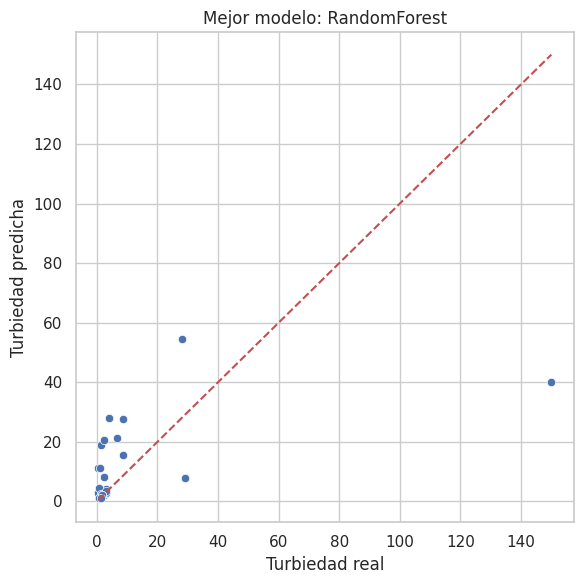

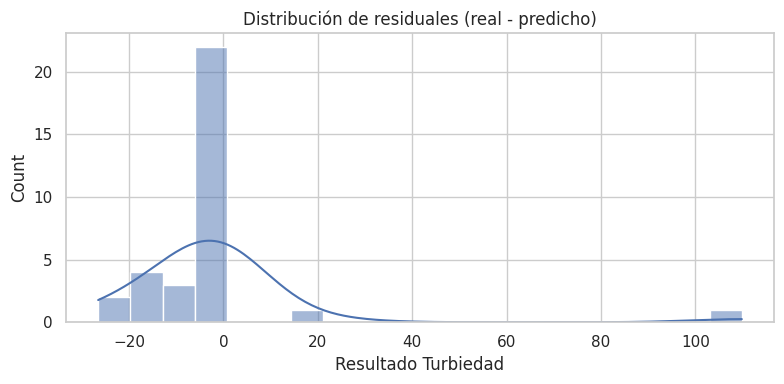

In [112]:
# Gráfico de predicción vs. gráfico real (mejor modelo)
best_is_rf = metrics_df.iloc[0]['modelo'] == 'RandomForest'
use_pred = pred_rf if best_is_rf else pred_ridge

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=use_pred)
lims = [min(y_test.min(), use_pred.min()), max(y_test.max(), use_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Turbiedad real')
plt.ylabel('Turbiedad predicha')
plt.title('Mejor modelo: ' + metrics_df.iloc[0]['modelo'])
plt.tight_layout()
plt.show()

# Residuales
resid = y_test - use_pred
plt.figure(figsize=(8,4))
sns.histplot(resid, bins=20, kde=True)
plt.title('Distribución de residuales (real - predicho)')
plt.tight_layout()
plt.show()

### Gráfico de Predicción vs. Real (Mejor Modelo)

Este gráfico de dispersión compara los valores de `Turbiedad` **reales** (eje X) con los valores de `Turbiedad` **predichos** por el mejor modelo (eje Y). La línea roja discontinua representa la predicción perfecta, donde los valores predichos serían exactamente iguales a los valores reales.

*   **Interpretación:** Cuanto más cerca estén los puntos de la línea roja, mejor es la capacidad del modelo para predecir la turbidez. Si todos los puntos cayeran exactamente sobre la línea, el modelo sería perfecto. La dispersión de los puntos alrededor de esta línea nos da una idea visual del rendimiento del modelo. Una mayor dispersión indica una menor precisión en las predicciones.

### Distribución de Residuales (Real - Predicho)

Este histograma muestra la distribución de los **residuales**, que son las diferencias entre los valores reales de `Turbiedad` y los valores predichos por el modelo (`real - predicho`).

*   **Interpretación:** En un modelo ideal, los residuales deben distribuirse de manera normal alrededor de cero (es decir, parecerse a una campana de Gauss centrada en cero). Esto indicaría que el modelo no tiene un sesgo sistemático (no subestima ni sobrestima consistentemente las predicciones) y que los errores son aleatorios. Si la distribución es asimétrica, tiene múltiples picos o no está centrada en cero, sugiere que el modelo podría mejorarse o que hay patrones no capturados en los datos.

# Predicción de % IRCA (Laboratorio) y Análisis de Importancia de Características

Este análisis se centró en predecir el **% IRCA (Laboratorio)** utilizando diversas variables químicas y físicas del conjunto de datos `Relación de muestras`. Se emplearon dos modelos de aprendizaje automático:

1.  **Regresión Ridge:** Un tipo de regresión lineal con regularización. Su rendimiento fue extremadamente bajo (R² negativo), indicando que una relación lineal no es adecuada para capturar la complejidad de la variable objetivo en este contexto.
2.  **RandomForest Regressor:** Un modelo de conjunto robusto basado en árboles de decisión. Este modelo demostró una capacidad predictiva significativamente mejor.



In [129]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

target_col2 = '% IRCA (Laboratorio)'

# Obtener todas las columnas numéricas de df_etl
num_df_all = df_etl.select_dtypes(include=[np.number]).copy()

# Excluir las columnas de identificadores que no son características predictivas.
exclude_id_cols = ['ID del prestador', 'Código DANE (municipio de toma de muestra)', 'lat_decimal',
    'lon_decimal', 'Latitud - N - º (grados)', "Latitud - N - ' (minutos)", "Latitud - N - '' (segundos)",
    'Longitud - W - º (grados)', "Longitud - W - ' (minutos)", "Longitud - W - '' (segundos)",
    'Tipo de muestra']
num_df_all = num_df_all.drop(columns=[col for col in exclude_id_cols if col in num_df_all.columns])

# Calcular la tasa de valores no nulos para estas columnas numéricas.
non_null_rate_all_num = 1 - num_df_all.isna().mean()

# Filtra las columnas con al menos un 60 % de valores no nulos y excluye la columna objetivo.
# Excluye todas las columnas 'Incertidumbre'
feature_cols2 = [
    c for c in non_null_rate_all_num[non_null_rate_all_num >= 0.6].index.tolist()
    if c != target_col2 and 'Incertidumbre' not in c
]

# Crea un modelo_df específicamente para la predicción de turbidez, eliminando las filas donde el objetivo sea NaN.
model_df_turbidity = df_etl[[target_col2] + feature_cols2].copy()
model_df_turbidity = model_df_turbidity.dropna(subset=[target_col2])

X = model_df_turbidity[feature_cols2]
y = model_df_turbidity[target_col2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

ridge_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))
])

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        min_samples_leaf=3,
        n_jobs=-1
    ))
])

ridge_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

pred_ridge = ridge_pipe.predict(X_test)
pred_rf = rf_pipe.predict(X_test)

rmse_ridge = float(np.sqrt(mean_squared_error(y_test, pred_ridge)))
rmse_rf = float(np.sqrt(mean_squared_error(y_test, pred_rf)))

metrics_df = pd.DataFrame({
    'modelo': ['Ridge', 'RandomForest'],
    'R2': [r2_score(y_test, pred_ridge), r2_score(y_test, pred_rf)],
    'MAE': [mean_absolute_error(y_test, pred_ridge), mean_absolute_error(y_test, pred_rf)],
    'RMSE': [rmse_ridge, rmse_rf]
}).sort_values('R2', ascending=False)

print(metrics_df)

# Coeficientes
# Se usa feature_cols2 para ridge_coefs ya que representa las columnas usadas en el entrenamiento
ridge_coefs = pd.Series(ridge_pipe.named_steps['model'].coef_, index=feature_cols2).sort_values(key=lambda s: s.abs(), ascending=False)
rf_imp = pd.Series(rf_pipe.named_steps['model'].feature_importances_, index=feature_cols2).sort_values(ascending=False)

print('\nTop 10 Coeficientes del Modelo Ridge:')
display(ridge_coefs.head(10).rename(lambda x: x.replace('Resultado ', '')))
print('\nTop 10 Importancia de Características del Modelo RandomForest:')
display(rf_imp.head(10).rename(lambda x: x.replace('Resultado ', '')))

         modelo          R2         MAE        RMSE
1  RandomForest    0.605911   14.637688   17.790782
0         Ridge -399.705444  106.560647  567.297148

Top 10 Coeficientes del Modelo Ridge:


,0
real Cloro Libre,-24.682002
Cloro Libre,16.651685
Conductividad,12.300413
Alcalinidad Total,-11.299254
Cloruros,-7.868975
Turbiedad,4.102449
pH,3.098875
Magnesio,-2.999528
Sulfatos,-1.986467
Temperatura,-1.909344



Top 10 Importancia de Características del Modelo RandomForest:


,0
Turbiedad,0.384662
real Cloro Libre,0.273782
Cloruros,0.078180
Nitratos,0.039016
Calcio,0.033562
pH,0.027096
COT,0.026297
Sulfatos,0.025882
Dureza Total,0.024147
Temperatura,0.022827


#### **Resultados Clave del Análisis:**

*   El **RandomForest Regressor** fue el modelo con mejor rendimiento, logrando un **R² de aproximadamente 0.6059**. Esto significa que el modelo puede explicar alrededor del 60.59% de la varianza en el % IRCA (Laboratorio).
*   La **Regresión Ridge** obtuvo un rendimiento muy deficiente (R² de -399.70), lo que sugiere que las relaciones entre las variables predictoras y el % IRCA son no lineales.

#### **Características más Importantes (según RandomForest):**

Las variables que el modelo RandomForest identificó como las más cruciales para predecir el % IRCA (Laboratorio) son:

1.  **Turbiedad:** Demostrando ser el factor más influyente.
2.  **Cloro Libre real**
3.  **Cloruros**
4.  **Nitratos**
5.  **Calcio**
6.  **pH**
7.  **COT (Carbono Orgánico Total)**
8.  **Sulfatos**
9.  **Dureza Total**
10. **Temperatura**

Estos hallazgos sugieren que los parámetros relacionados con la turbidez, la desinfección (cloro), y la presencia de ciertos iones y compuestos orgánicos son los principales indicadores de riesgo en la calidad del agua, de acuerdo con este modelo predictivo.

### Visualización del Rendimiento del Modelo de Predicción de % IRCA (Laboratorio)

A continuación, se presentan gráficos que ilustran el rendimiento del mejor modelo predictivo (RandomForest) para el `% IRCA (Laboratorio)`.

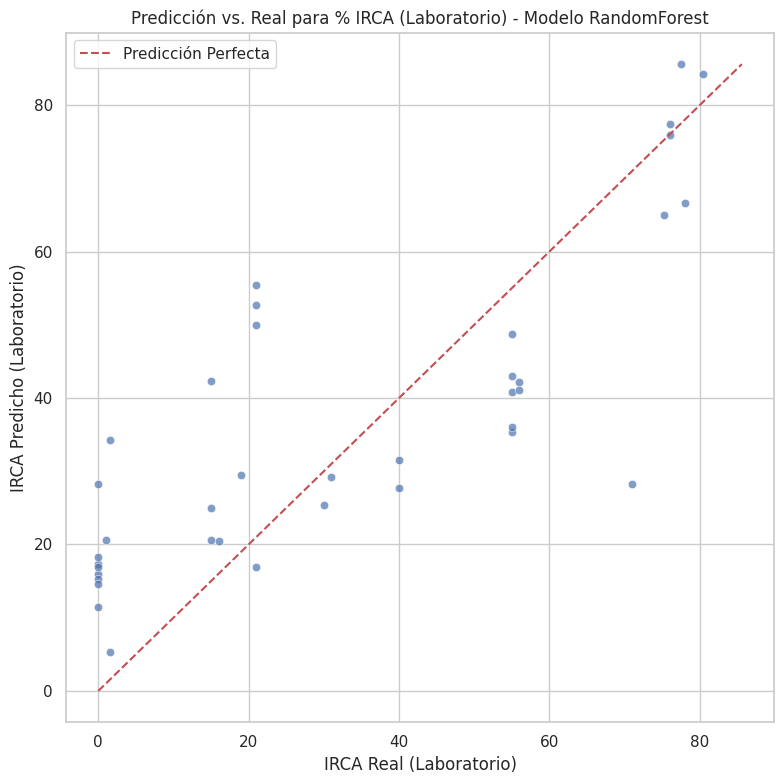

In [130]:
# Gráfico de predicción vs. real para el mejor modelo (RandomForest)
plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=pred_rf, alpha=0.7)
lims = [min(y_test.min(), pred_rf.min()), max(y_test.max(), pred_rf.max())]
plt.plot(lims, lims, 'r--', label='Predicción Perfecta')
plt.title('Predicción vs. Real para % IRCA (Laboratorio) - Modelo RandomForest')
plt.xlabel('IRCA Real (Laboratorio)')
plt.ylabel('IRCA Predicho (Laboratorio)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Interpretación del Gráfico de Predicción vs. Real:

Este gráfico de dispersión compara los valores reales del `% IRCA (Laboratorio)` (eje X) con los valores predichos por el modelo RandomForest (eje Y). La línea roja discontinua representa la situación ideal donde las predicciones coinciden perfectamente con los valores reales. Cuanto más cerca se agrupan los puntos alrededor de esta línea, mejor es la capacidad predictiva del modelo. Una dispersión amplia de los puntos indica que el modelo tiene dificultades para predecir con precisión en ciertos rangos o que hay variabilidad no explicada por las características utilizadas.

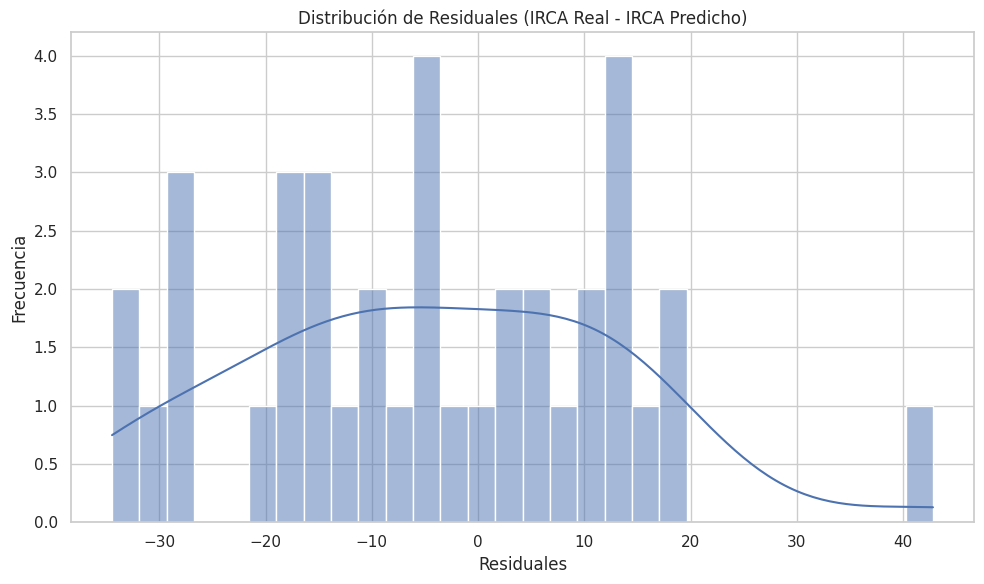

In [131]:
# Distribución de Residuales
resid_irca = y_test - pred_rf
plt.figure(figsize=(10, 6))
sns.histplot(resid_irca, bins=30, kde=True)
plt.title('Distribución de Residuales (IRCA Real - IRCA Predicho)')
plt.xlabel('Residuales')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Interpretación de la Distribución de Residuales:

Este histograma muestra la distribución de los errores del modelo (residuales = valor real - valor predicho). Idealmente, los residuales deben seguir una distribución normal centrada en cero. Una distribución centrada en cero sugiere que el modelo no tiene un sesgo sistemático (no subestima ni sobreestima consistentemente). La forma de la distribución puede indicar si el modelo está capturando adecuadamente la relación entre las variables o si existen patrones no lineales que aún no se han modelado.

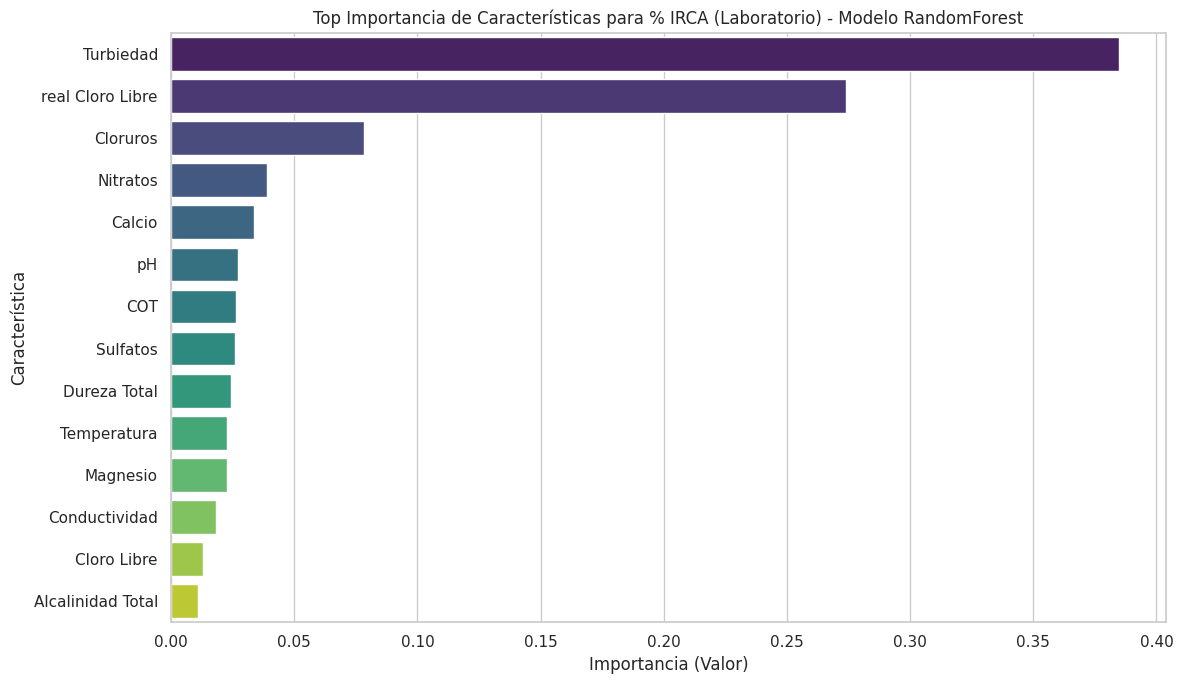

In [134]:
# Gráfico de barras de la importancia de características del RandomForest
plt.figure(figsize=(12, 7))
sns.barplot(x=rf_imp.values, y=rf_imp.index.str.replace('Resultado ', ''), palette='viridis', hue=rf_imp.index.str.replace('Resultado ', ''), legend=False)
plt.title('Top Importancia de Características para % IRCA (Laboratorio) - Modelo RandomForest')
plt.xlabel('Importancia (Valor)')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

#### Interpretación del Gráfico de Importancia de Características:

Este gráfico de barras visualiza la importancia relativa de cada característica en la predicción del `% IRCA (Laboratorio)` por el modelo RandomForest. Las características con barras más largas son las que más contribuyen a las predicciones del modelo. Esto nos permite identificar los factores clave que el modelo considera más influyentes en la determinación del índice de riesgo de la calidad del agua, como la `Turbiedad` y el `Cloro Libre real`.